In [1]:
import openai
import pandas as pd
import numpy as np
import re
import sys, os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import ast
import re
import json
from tqdm import tqdm

In [2]:
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[0]
sys.path.append(str(repo_path))

In [3]:
from py.utils import verifyDir

In [4]:
API_KEY = os.environ.get('OPENAI_API_KEY', '')
DATA_PATH = f"{repo_path}/data/"
ARTICLES_PATH = f"{DATA_PATH}articles/"
CSV_PATH=f"{repo_path}/outputs/csv/"

In [5]:
verifyDir(CSV_PATH)

### Loading graph

In [6]:
edge_category = {
    'Event.Invest': 'Positive',
    'Event.Aid': 'Positive',
    'Event.Fishing.SustainableFishing': 'Positive',
    'Event.Applaud': 'Positive',
    'Event.CertificateIssued': 'Positive',
    'Event.Communication.Conference': 'Positive',
    'Event.Transaction': 'Neutral',
    'Event.Owns.PartiallyOwns': 'Neutral',
    'Event.Fishing': 'Neutral',
    'Event.Fishing.OverFishing': 'Negative',
    'Event.Criticize': 'Negative',
    'Event.CertificateIssued.Summons': 'Negative',
    'Event.Convicted': 'Negative'
}

edge_category_lower = {key.lower(): value for key, value in edge_category.items()}


In [7]:
df = pd.read_csv(f"{DATA_PATH}csv/graph.csv", sep=",", low_memory=False)
df["source"] = df["source"].apply(lambda x: x.lower())
# df["type"] = df["type"].apply(lambda x: x.lower())
df["target"] = df["target"].apply(lambda x: x.lower())
df["_last_edited_date"] = df["_last_edited_date"].apply(lambda x: x.split(" ")[0])
df["_date_added"] = df["_date_added"].apply(lambda x: x.split(" ")[0])
df["new_type"] = df["type"].apply(lambda x: edge_category[x])
df

,source,source_type,type,weight,target,target_type,_last_edited_by,_last_edited_date,_date_added,_date,_raw_source,_algorithm,_articleid,new_type
0,frey inc,Entity.Organization.FishingCompany,Event.Invest,1,sustainable_nets,Entity.Commodity,Jack Inch,2035-02-01,2035-02-01,2035-02-01,The News Buoy,BassLine,Frey Inc__0__0__The News Buoy,Positive
1,city of port grove,Entity.Organization.GovernmentOrg,Event.CertificateIssued,1,barnes and sons,Entity.Organization.FishingCompany,Kristin Baker,2035-02-01,2035-02-01,2035-02-01,Lomark Daily,BassLine,Barnes and Sons__0__0__Lomark Daily,Positive
2,castillo-elliott,Entity.Organization.FishingCompany,Event.Fishing,0,tuna shelf,Entity.Location.Region,Junior Shurdlu,2035-02-01,2035-02-01,2035-02-01,Haacklee Herald,BassLine,Castillo-Elliott__0__0__Haacklee Herald,Neutral
3,city of lomark,Entity.Organization.GovernmentOrg,Event.Applaud,1,frey inc,Entity.Organization.FishingCompany,Jack Inch,2035-02-01,2035-02-01,2035-02-01,The News Buoy,BassLine,Frey Inc__0__0__The News Buoy,Positive
4,barnes and sons,Entity.Organization.FishingCompany,Event.Transaction,0,ramos-shelton,Entity.Organization.FishingCompany,Kristin Baker,2035-02-01,2035-02-01,2035-02-01,Lomark Daily,BassLine,Barnes and Sons__0__0__Lomark Daily,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14195,sanchez-moreno,Entity.Organization.FishingCompany,Event.Invest,1,tracking_system,Entity.Commodity,Greta Grass-Hill,2035-07-30,2035-07-30,2035-07-30,Lomark Daily,BassLine,Sanchez-Moreno__0__1__Lomark Daily,Positive
14196,sanchez-moreno,Entity.Organization.FishingCompany,Event.Aid,1,marine_sanctuary,Entity.Organization,Greta Grass-Hill,2035-07-30,2035-07-30,2035-07-30,Lomark Daily,BassLine,Sanchez-Moreno__0__1__Lomark Daily,Positive
14197,"taylor, prince and sherman",Entity.Organization.FishingCompany,Event.Invest,1,efficiency,Entity.Commodity,Worf Peer,2035-07-30,2035-07-30,2035-07-30,Lomark Daily,ShadGPT,"Taylor, Prince and Sherman__0__1__Lomark Daily",Positive
14198,"bell, reynolds and forbes",Entity.Organization.FishingCompany,Event.Invest,1,efficiency,Entity.Commodity,Olokun Daramola,2035-07-30,2035-07-30,2035-07-30,Lomark Daily,ShadGPT,"Bell, Reynolds and Forbes__0__1__Lomark Daily",Positive


In [8]:
df[df["target"]=="southseafood express corp"]

,source,source_type,type,weight,target,target_type,_last_edited_by,_last_edited_date,_date_added,_date,_raw_source,_algorithm,_articleid,new_type
10258,city of himark,Entity.Organization.GovernmentOrg,Event.Applaud,1,southseafood express corp,Entity.Organization.FishingCompany,Harvey Janus,2035-06-10,2035-06-07,2035-06-07,Lomark Daily,BassLine,Jones Group__0__0__Lomark Daily,Positive
10260,city of south paackland,Entity.Organization.GovernmentOrg,Event.Applaud,1,southseafood express corp,Entity.Organization.FishingCompany,Harvey Janus,2035-06-10,2035-06-07,2035-06-07,Lomark Daily,BassLine,Jones Group__0__0__Lomark Daily,Positive
10268,city of himark,Entity.Organization.GovernmentOrg,Event.Applaud,1,southseafood express corp,Entity.Organization.FishingCompany,Harvey Janus,2035-06-10,2035-06-07,2035-06-07,The News Buoy,BassLine,Jones Group__0__0__The News Buoy,Positive
10279,city of south paackland,Entity.Organization.GovernmentOrg,Event.Applaud,1,southseafood express corp,Entity.Organization.FishingCompany,Harvey Janus,2035-06-10,2035-06-07,2035-06-07,The News Buoy,BassLine,Jones Group__0__0__The News Buoy,Positive
10306,city of south paackland,Entity.Organization.GovernmentOrg,Event.Applaud,1,southseafood express corp,Entity.Organization.FishingCompany,Harvey Janus,2035-06-10,2035-06-07,2035-06-07,Haacklee Herald,BassLine,Jones Group__0__0__Haacklee Herald,Positive
10314,city of himark,Entity.Organization.GovernmentOrg,Event.Applaud,1,southseafood express corp,Entity.Organization.FishingCompany,Harvey Janus,2035-06-10,2035-06-07,2035-06-07,Haacklee Herald,BassLine,Jones Group__0__0__Haacklee Herald,Positive


In [9]:
df[df["target"]=="irtysh creek logistics inc"]

,source,source_type,type,weight,target,target_type,_last_edited_by,_last_edited_date,_date_added,_date,_raw_source,_algorithm,_articleid,new_type
12012,city of south paackland,Entity.Organization.GovernmentOrg,Event.CertificateIssued.Summons,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Worf Peer,2035-06-29,2035-06-29,2035-06-29,Lomark Daily,ShadGPT,Jones Group__0__0__Lomark Daily,Negative
12013,city of himark,Entity.Organization.GovernmentOrg,Event.CertificateIssued.Summons,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Worf Peer,2035-06-29,2035-06-29,2035-06-29,Lomark Daily,ShadGPT,Jones Group__0__0__Lomark Daily,Negative
12014,city of south paackland,Entity.Organization.GovernmentOrg,Event.Convicted,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Worf Peer,2035-06-29,2035-06-29,2035-06-29,South Paackland Police Reports,ShadGPT,Jones Group__0__0__Lomark Daily,Negative
12030,city of south paackland,Entity.Organization.GovernmentOrg,Event.CertificateIssued.Summons,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Niklaus Oberon,2035-06-29,2035-06-29,2035-06-29,South Paackland Police Reports,ShadGPT,Jones Group__0__0__Haacklee Herald,Negative
12031,city of south paackland,Entity.Organization.GovernmentOrg,Event.CertificateIssued.Summons,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Niklaus Oberon,2035-06-29,2035-06-29,2035-06-29,Haacklee Herald,ShadGPT,Jones Group__0__0__Haacklee Herald,Negative
12032,city of himark,Entity.Organization.GovernmentOrg,Event.CertificateIssued.Summons,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Niklaus Oberon,2035-06-29,2035-06-29,2035-06-29,Haacklee Herald,ShadGPT,Jones Group__0__0__Haacklee Herald,Negative
12044,city of himark,Entity.Organization.GovernmentOrg,Event.CertificateIssued.Summons,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Worf Peer,2035-06-29,2035-06-29,2035-06-29,The News Buoy,ShadGPT,Jones Group__0__0__The News Buoy,Negative
12045,city of south paackland,Entity.Organization.GovernmentOrg,Event.CertificateIssued.Summons,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Worf Peer,2035-06-29,2035-06-29,2035-06-29,South Paackland Police Reports,ShadGPT,Jones Group__0__0__The News Buoy,Negative
12046,city of south paackland,Entity.Organization.GovernmentOrg,Event.CertificateIssued.Summons,-1,irtysh creek logistics inc,Entity.Organization.LogisticsCompany,Worf Peer,2035-06-29,2035-06-29,2035-06-29,The News Buoy,ShadGPT,Jones Group__0__0__The News Buoy,Negative


### Dividing

In [10]:
bassLine = df[df["_algorithm"]=="BassLine"].copy()
shadGPT = df[df["_algorithm"]=="ShadGPT"].copy()

### Size

In [11]:
bassLine.shape, shadGPT.shape

((7294, 14), (6906, 14))

### Nodes

In [12]:
bassLine_nodes = set( set( bassLine["source"].unique() ).union( set(bassLine["target"].unique()) ))
len(bassLine_nodes), bassLine_nodes

(197,
 {'6. america transit plc',
  'agualeska transit n.v.',
  'allen-weiss',
  'alvarez plc',
  'anderson, brown and green',
  'arawakfish cargo ges.m.b.h.',
  'archer-johnson',
  'arellano group',
  'bailey-mccullough',
  'baringoamerica marine ges.m.b.h.',
  'barnes and sons',
  'barnett ltd',
  'bates-anderson',
  'bell, reynolds and forbes',
  'bishop-hernandez',
  'blackwell, clark and lam',
  'bowers group',
  'brown, clarke and martinez',
  'brown-stokes',
  'bryant, macdonald and howard',
  'burns inc',
  'cain, simpson and hernandez',
  'castillo-elliott',
  'cervantes-kramer',
  'chapman, hall and miller',
  'chavez, anderson and taylor',
  'cisneros-meyer',
  'city of centralia',
  'city of himark',
  'city of lomark',
  'city of paackland',
  'city of port grove',
  'city of south paackland',
  'clark-leon',
  'clarke, scott and sloan',
  'clements, allen and sullivan',
  'cod table',
  'coleman, nelson and garcia',
  'coleman, thompson and huber',
  'collins, johnson and

In [13]:
shadGPT_nodes = set( set( shadGPT["source"].unique() ).union( set(shadGPT["target"].unique()) ) )
len(shadGPT_nodes), shadGPT_nodes

(197,
 {'6. america transit plc',
  'agualeska transit n.v.',
  'allen-weiss',
  'alvarez plc',
  'anderson, brown and green',
  'arawakfish cargo ges.m.b.h.',
  'archer-johnson',
  'arellano group',
  'bailey-mccullough',
  'baringoamerica marine ges.m.b.h.',
  'barnes and sons',
  'barnett ltd',
  'bates-anderson',
  'bell, reynolds and forbes',
  'bishop-hernandez',
  'blackwell, clark and lam',
  'bowers group',
  'brown, clarke and martinez',
  'brown-stokes',
  'bryant, macdonald and howard',
  'burns inc',
  'cain, simpson and hernandez',
  'castillo-elliott',
  'cervantes-kramer',
  'chapman, hall and miller',
  'chavez, anderson and taylor',
  'cisneros-meyer',
  'city of centralia',
  'city of himark',
  'city of lomark',
  'city of paackland',
  'city of port grove',
  'city of south paackland',
  'clark-leon',
  'clarke, scott and sloan',
  'clements, allen and sullivan',
  'cod table',
  'coleman, nelson and garcia',
  'coleman, thompson and huber',
  'collins, johnson and

In [14]:
shadGPT_nodes - bassLine_nodes

{'irtysh creek logistics inc'}

In [15]:
bassLine_nodes - shadGPT_nodes

{'southseafood express corp'}

### Edges

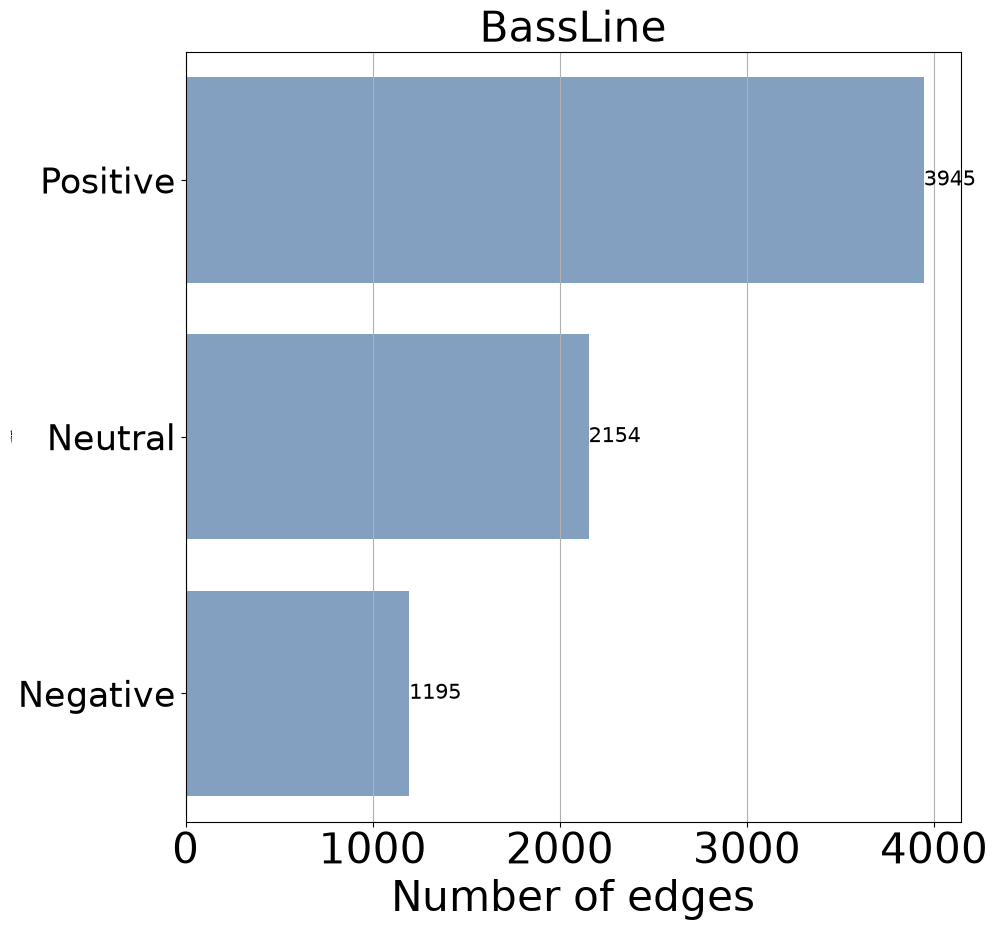

In [16]:
_, ax = plt.subplots(figsize=(10,10), nrows=1, ncols=1, sharex=False, sharey=False)

# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["new_type"].value_counts().reset_index()
data_df = bassLine["new_type"].value_counts().reset_index()
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="#799fcb",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

sns_fig.set_title(f"BassLine", fontsize=30)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'Number of edges', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

# ax.grid(True)
ax.xaxis.grid()

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

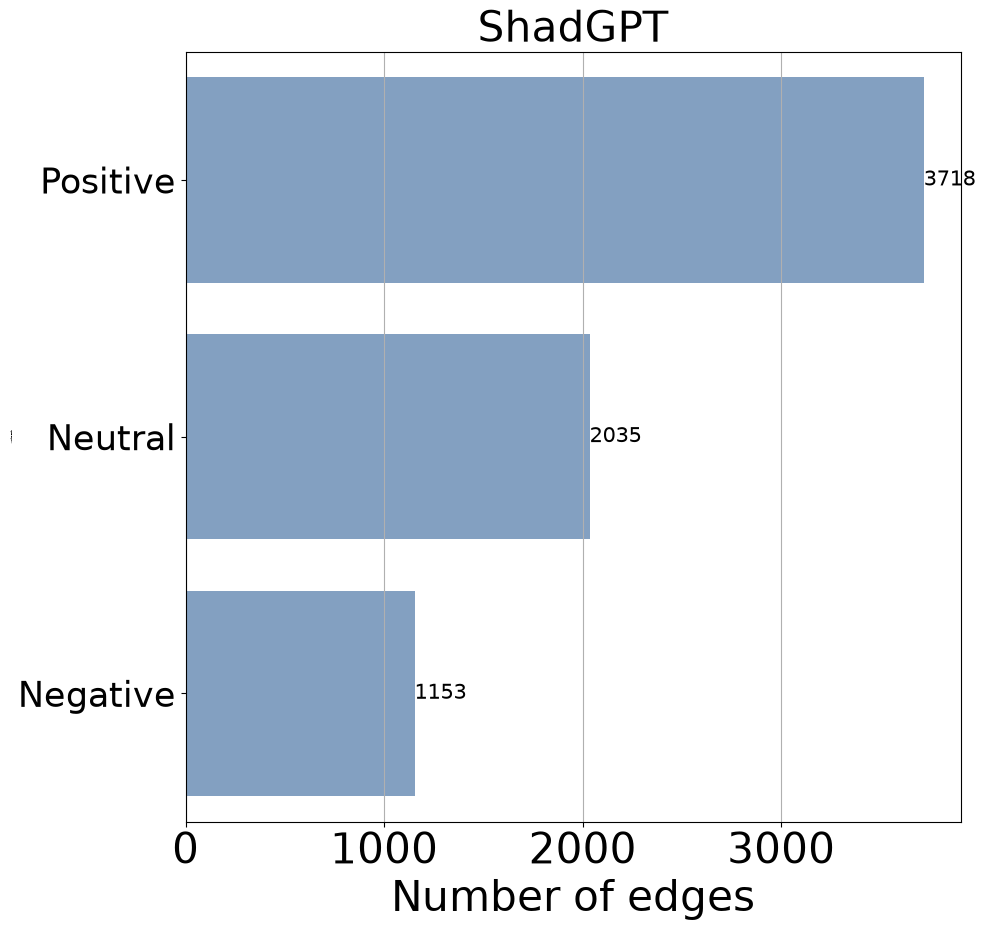

In [17]:
_, ax = plt.subplots(figsize=(10,10), nrows=1, ncols=1, sharex=False, sharey=False)

# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["new_type"].value_counts().reset_index()
data_df = shadGPT["new_type"].value_counts().reset_index()
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="#799fcb",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

sns_fig.set_title(f"ShadGPT", fontsize=30)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'Number of edges', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

# ax.grid(True)
ax.xaxis.grid()

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

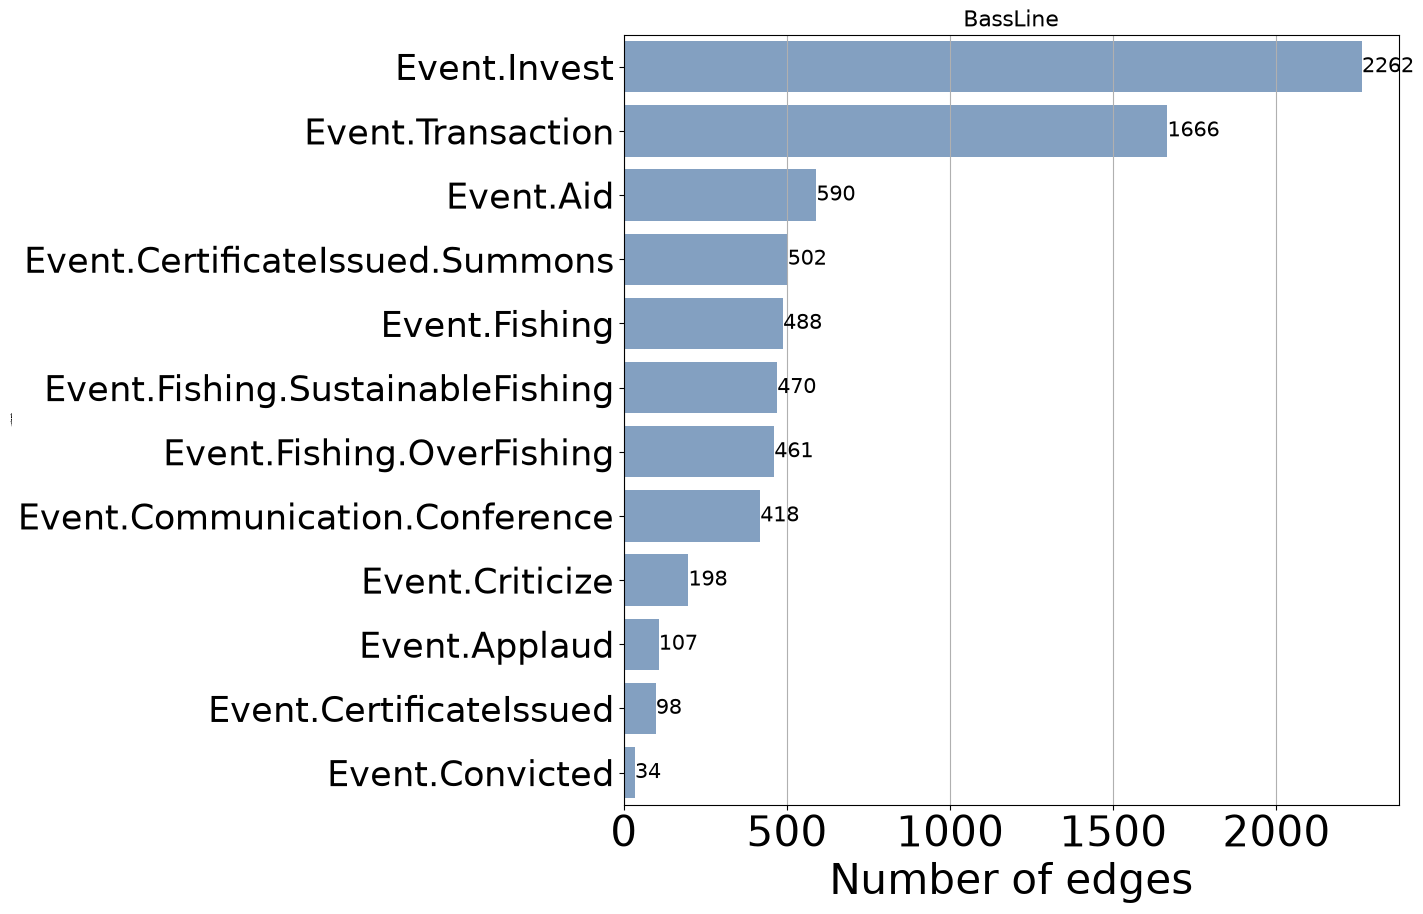

In [18]:
_, ax = plt.subplots(figsize=(10,10), nrows=1, ncols=1, sharex=False, sharey=False)

# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["new_type"].value_counts().reset_index()
data_df = bassLine["type"].value_counts().reset_index()
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="#799fcb",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

sns_fig.set_title(f"BassLine", fontsize=16)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'Number of edges', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

# ax.grid(True)
ax.xaxis.grid()

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

In [19]:
len (set(df["source"].values).union(set(df["target"].values)) )

198

In [20]:
df[ df["_last_edited_date"]!=df["_date_added"] ]["_algorithm"].value_counts() 

_algorithm
BassLine    14
Name: count, dtype: int64

In [21]:
df["_algorithm"].value_counts() 

_algorithm
BassLine    7294
ShadGPT     6906
Name: count, dtype: int64

In [22]:
source_map = dict(zip(df["source"], df["source_type"]))
target_map = dict(zip(df["target"], df["target_type"]))

In [23]:
# list( df[ (df["source"]=="Alvarez PLC") & (df["_raw_source"]=="Lomark Daily") ][["source", "type", "target"] ].drop_duplicates().copy().itertuples(index=False, name=None)  )

In [24]:
shadGPT = df[ df["_algorithm"]=="ShadGPT" ][["source", "type", "target", "_articleid", "_date_added", "_last_edited_date", "_last_edited_by"] ].drop_duplicates().copy()
bassLine = df[ df["_algorithm"]=="BassLine" ][["source", "type", "target", "_articleid", "_date_added", "_last_edited_date", "_last_edited_by"] ].drop_duplicates().copy()

In [25]:
bassLine.shape, shadGPT.shape, 

((7151, 7), (6784, 7))

In [26]:
shadGPT[shadGPT["_date_added"]!=shadGPT["_last_edited_date"]].to_csv(f"{CSV_PATH}shadGPT_editions.csv", sep="\t", index=False)
shadGPT[shadGPT["_date_added"]!=shadGPT["_last_edited_date"]]

,source,type,target,_articleid,_date_added,_last_edited_date,_last_edited_by


In [27]:
bassLine[bassLine["_date_added"]!=bassLine["_last_edited_date"]].to_csv(f"{CSV_PATH}bassLine_editions.csv", sep="\t", index=False)
bassLine[bassLine["_date_added"]!=bassLine["_last_edited_date"]]

,source,type,target,_articleid,_date_added,_last_edited_date,_last_edited_by
10256,southseafood express corp,Event.Fishing.SustainableFishing,tuna shelf,Jones Group__0__0__Lomark Daily,2035-06-07,2035-06-10,Harvey Janus
10257,southseafood express corp,Event.Applaud,oceanus guardians alliance,Jones Group__0__0__Lomark Daily,2035-06-07,2035-06-10,Harvey Janus
10258,city of himark,Event.Applaud,southseafood express corp,Jones Group__0__0__Lomark Daily,2035-06-07,2035-06-10,Harvey Janus
10259,southseafood express corp,Event.Fishing.SustainableFishing,cod table,Jones Group__0__0__Lomark Daily,2035-06-07,2035-06-10,Harvey Janus
10260,city of south paackland,Event.Applaud,southseafood express corp,Jones Group__0__0__Lomark Daily,2035-06-07,2035-06-10,Harvey Janus
10268,city of himark,Event.Applaud,southseafood express corp,Jones Group__0__0__The News Buoy,2035-06-07,2035-06-10,Harvey Janus
10272,southseafood express corp,Event.Applaud,paackland fishermen's rights enforcement network,Jones Group__0__0__The News Buoy,2035-06-07,2035-06-10,Harvey Janus
10277,southseafood express corp,Event.Fishing.SustainableFishing,tuna shelf,Jones Group__0__0__The News Buoy,2035-06-07,2035-06-10,Harvey Janus
10279,city of south paackland,Event.Applaud,southseafood express corp,Jones Group__0__0__The News Buoy,2035-06-07,2035-06-10,Harvey Janus
10282,southseafood express corp,Event.Fishing.SustainableFishing,cod table,Jones Group__0__0__The News Buoy,2035-06-07,2035-06-10,Harvey Janus


In [28]:
bassLine = bassLine[bassLine["_date_added"]==bassLine["_last_edited_date"]].drop_duplicates().copy()
shadGPT = shadGPT[shadGPT["_date_added"]==shadGPT["_last_edited_date"]].drop_duplicates().copy()

shadGPT = df[ df["_algorithm"]=="ShadGPT" ][["source", "type", "target", "_articleid", "_date_added", "_last_edited_date", "_last_edited_by"] ].drop_duplicates().copy()
bassLine = df[ df["_algorithm"]=="BassLine" ][["source", "type", "target", "_articleid", "_date_added", "_last_edited_date", "_last_edited_by"] ].drop_duplicates().copy()

In [29]:
bassLine.shape, shadGPT.shape, 

((7151, 7), (6784, 7))

In [30]:
both = pd.merge(shadGPT[["source", "type", "target", "_articleid"]].copy(), bassLine[["source", "type", "target", "_articleid"]].copy(), on=["source", "type", "target", "_articleid"], how='inner', indicator=True).sort_values(by="_articleid").drop_duplicates()
both

,source,type,target,_articleid,_merge
7742,alvarez plc,Event.Invest,safety,Alvarez PLC__0__0__Haacklee Herald,both
7739,alvarez plc,Event.Aid,marine_sanctuary,Alvarez PLC__0__0__Haacklee Herald,both
7744,alvarez plc,Event.Invest,tracking_system,Alvarez PLC__0__0__Haacklee Herald,both
2039,alvarez plc,Event.Invest,sustainable_nets,Alvarez PLC__0__0__Haacklee Herald,both
4790,alvarez plc,Event.Invest,efficiency,Alvarez PLC__0__0__Haacklee Herald,both
...,...,...,...,...,...
6605,wu-hart,Event.Fishing.SustainableFishing,cod table,Wu-Hart__0__0__The News Buoy,both
6606,wu-hart,Event.Fishing,cod table,Wu-Hart__0__0__The News Buoy,both
6607,wu-hart,Event.Invest,sustainable_nets,Wu-Hart__0__0__The News Buoy,both
8265,york-castillo,Event.Aid,marine_sanctuary,York-Castillo__0__0__Haacklee Herald,both


In [31]:
only_bassLine = pd.merge(bassLine, shadGPT, on=["source", "type", "target", "_articleid"], how='left', indicator=True)
only_bassLine[ only_bassLine["_merge"]=="left_only" ].sort_values(by="_articleid")

,source,type,target,_articleid,_date_added_x,_last_edited_date_x,_last_edited_by_x,_date_added_y,_last_edited_date_y,_last_edited_by_y,_merge
10799,alvarez plc,Event.Transaction,paul inc,Alvarez PLC__0__0__Haacklee Herald,2035-06-28,2035-06-28,Kristin Baker,NaN,NaN,NaN,left_only
12212,alvarez plc,Event.Communication.Conference,turner-green,Alvarez PLC__0__0__Haacklee Herald,2035-07-19,2035-07-19,Junior Shurdlu,NaN,NaN,NaN,left_only
2207,city of centralia,Event.CertificateIssued,alvarez plc,Alvarez PLC__0__0__Haacklee Herald,2035-02-27,2035-02-27,Olokun Daramola,NaN,NaN,NaN,left_only
2206,city of himark,Event.CertificateIssued,alvarez plc,Alvarez PLC__0__0__Haacklee Herald,2035-02-27,2035-02-27,Olokun Daramola,NaN,NaN,NaN,left_only
12209,alvarez plc,Event.Transaction,cervantes-kramer,Alvarez PLC__0__0__Haacklee Herald,2035-07-19,2035-07-19,Junior Shurdlu,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...
4631,york-castillo,Event.Invest,tracking_system,York-Castillo__0__0__The News Buoy,2035-04-03,2035-04-03,Haenyeo Hyun-Ki,NaN,NaN,NaN,left_only
4628,york-castillo,Event.Communication.Conference,"brown, clarke and martinez",York-Castillo__0__0__The News Buoy,2035-04-03,2035-04-03,Haenyeo Hyun-Ki,NaN,NaN,NaN,left_only
4625,york-castillo,Event.Fishing,tuna shelf,York-Castillo__0__0__The News Buoy,2035-04-03,2035-04-03,Haenyeo Hyun-Ki,NaN,NaN,NaN,left_only
4627,york-castillo,Event.Fishing.SustainableFishing,wrasse beds,York-Castillo__0__0__The News Buoy,2035-04-03,2035-04-03,Haenyeo Hyun-Ki,NaN,NaN,NaN,left_only


In [32]:
only_shadGPT = pd.merge(shadGPT, bassLine, on=["source", "type", "target", "_articleid"], how='left', indicator=True)
only_shadGPT[ only_shadGPT["_merge"]=="left_only" ].sort_values(by="_articleid")

,source,type,target,_articleid,_date_added_x,_last_edited_date_x,_last_edited_by_x,_date_added_y,_last_edited_date_y,_last_edited_by_y,_merge
2843,alvarez plc,Event.Transaction,"smith, smith and barber",Alvarez PLC__0__0__Haacklee Herald,2035-03-05,2035-03-05,Niklaus Oberon,NaN,NaN,NaN,left_only
10333,alvarez plc,Event.Transaction,barnes and sons,Alvarez PLC__0__0__Haacklee Herald,2035-06-23,2035-06-23,Junior Shurdlu,NaN,NaN,NaN,left_only
10334,alvarez plc,Event.Transaction,"maldonado, sanchez and jones",Alvarez PLC__0__0__Haacklee Herald,2035-06-23,2035-06-23,Junior Shurdlu,NaN,NaN,NaN,left_only
10335,alvarez plc,Event.Transaction,johnson-johnson,Alvarez PLC__0__0__Haacklee Herald,2035-06-23,2035-06-23,Junior Shurdlu,NaN,NaN,NaN,left_only
6400,alvarez plc,Event.Transaction,"vasquez, chaney and martinez",Alvarez PLC__0__0__Haacklee Herald,2035-04-25,2035-04-25,Harvey Janus,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...
11009,york-castillo,Event.Invest,sustainable_nets,York-Castillo__0__0__Haacklee Herald,2035-07-06,2035-07-06,Jack Inch,NaN,NaN,NaN,left_only
11011,york-castillo,Event.Fishing.SustainableFishing,cod table,York-Castillo__0__0__Haacklee Herald,2035-07-06,2035-07-06,Jack Inch,NaN,NaN,NaN,left_only
11013,york-castillo,Event.Transaction,wilcox-nelson,York-Castillo__0__0__Haacklee Herald,2035-07-06,2035-07-06,Jack Inch,NaN,NaN,NaN,left_only
10981,york-castillo,Event.Communication.Conference,hines-douglas,York-Castillo__0__0__The News Buoy,2035-07-06,2035-07-06,Melinda Manning,NaN,NaN,NaN,left_only


### Links for each one

### both

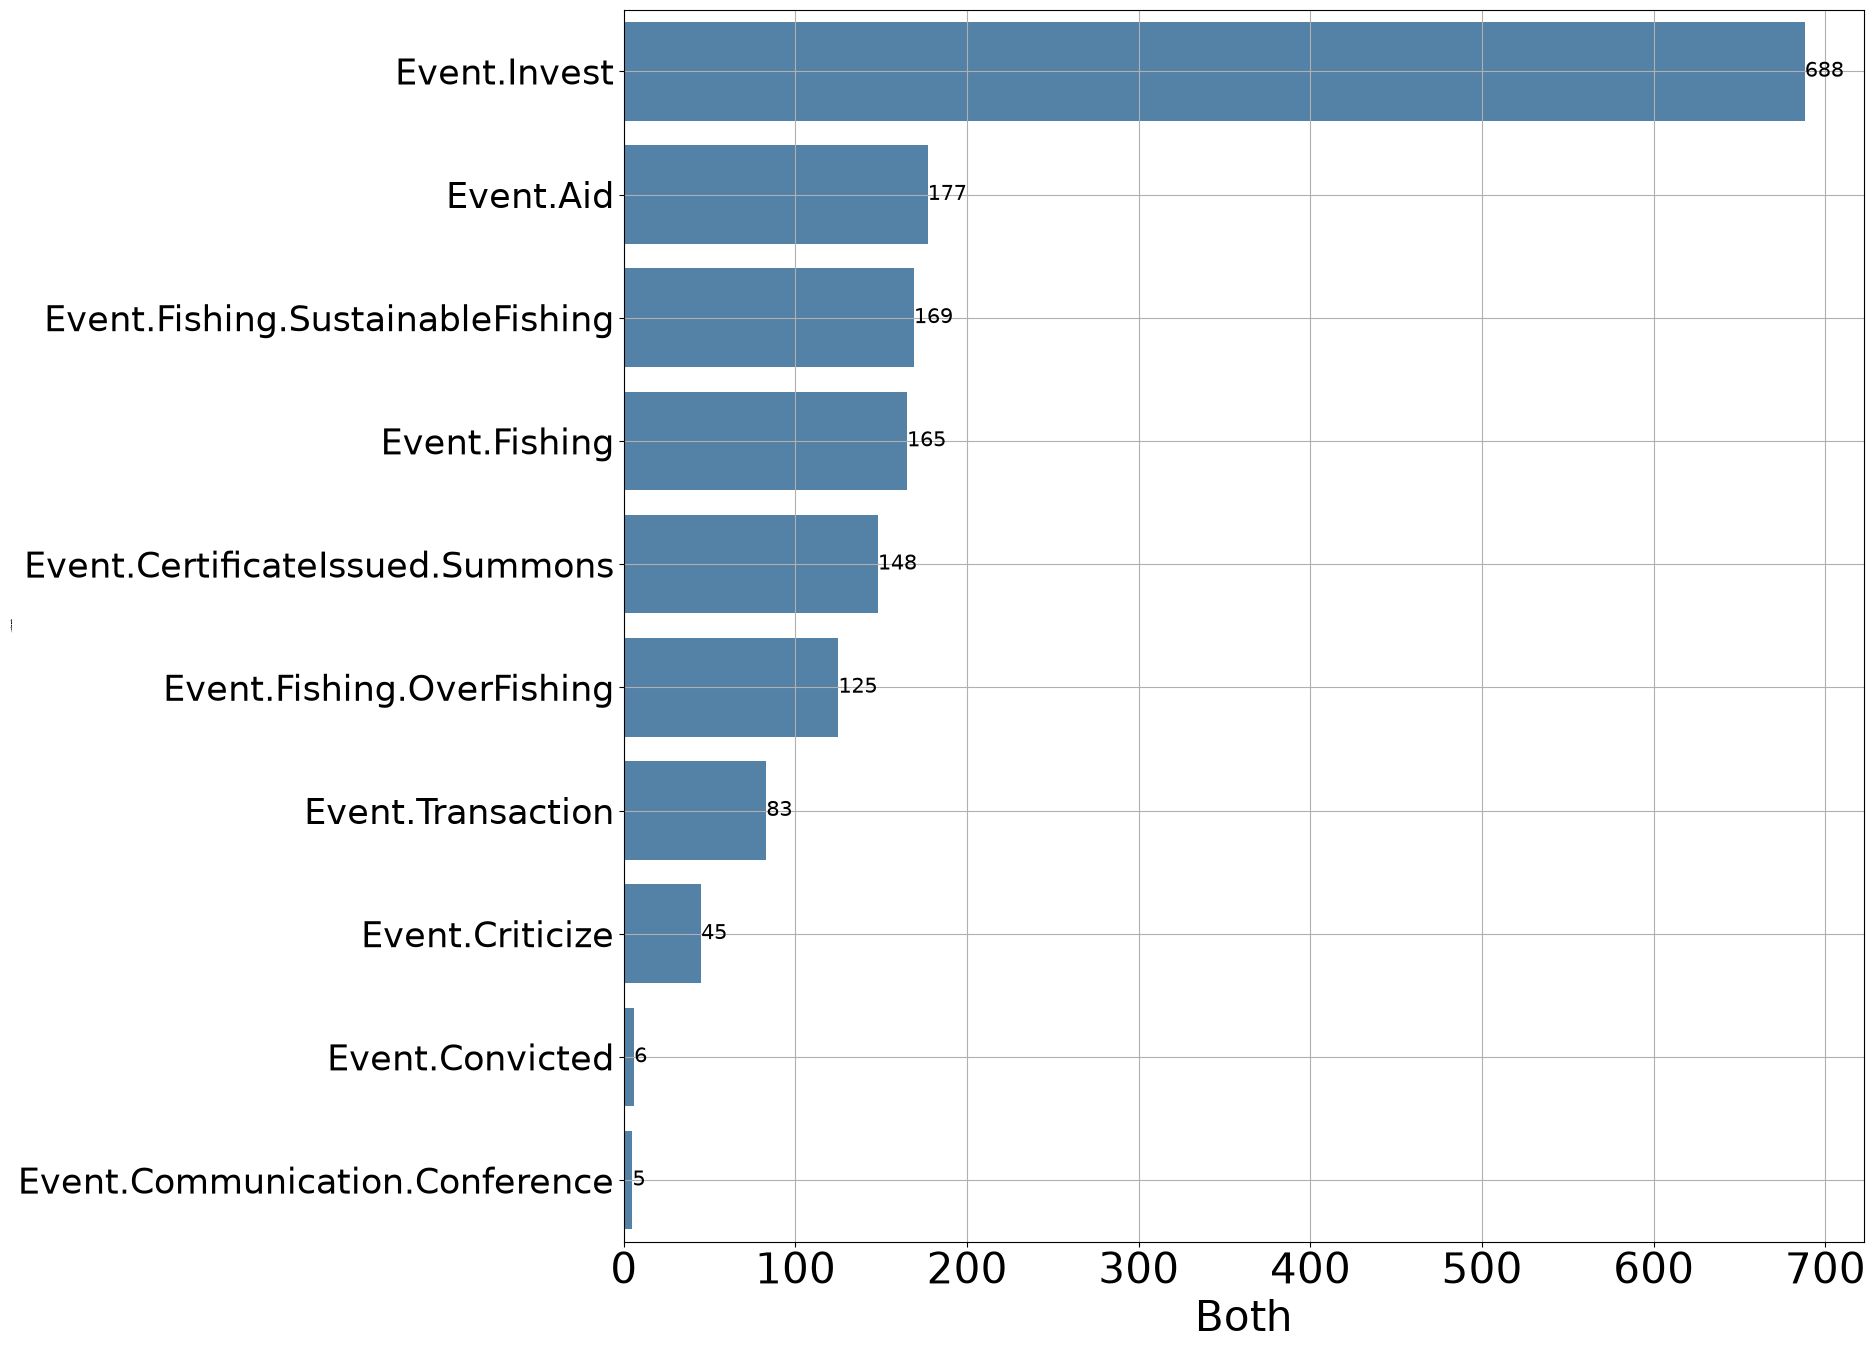

In [33]:
algorithm_name="ShadGPT"
_, ax = plt.subplots(figsize=(16,16), nrows=1, ncols=1, sharex=False, sharey=False)

data_df = both["type"].value_counts().reset_index()
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="steelblue",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

#sns_fig.set_title(f"Number of CVE-IDs cited per user, Total: {user_cve_sum}, Avg: {user_cve_mean}", fontsize=16)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'Both', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

ax.grid(True)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

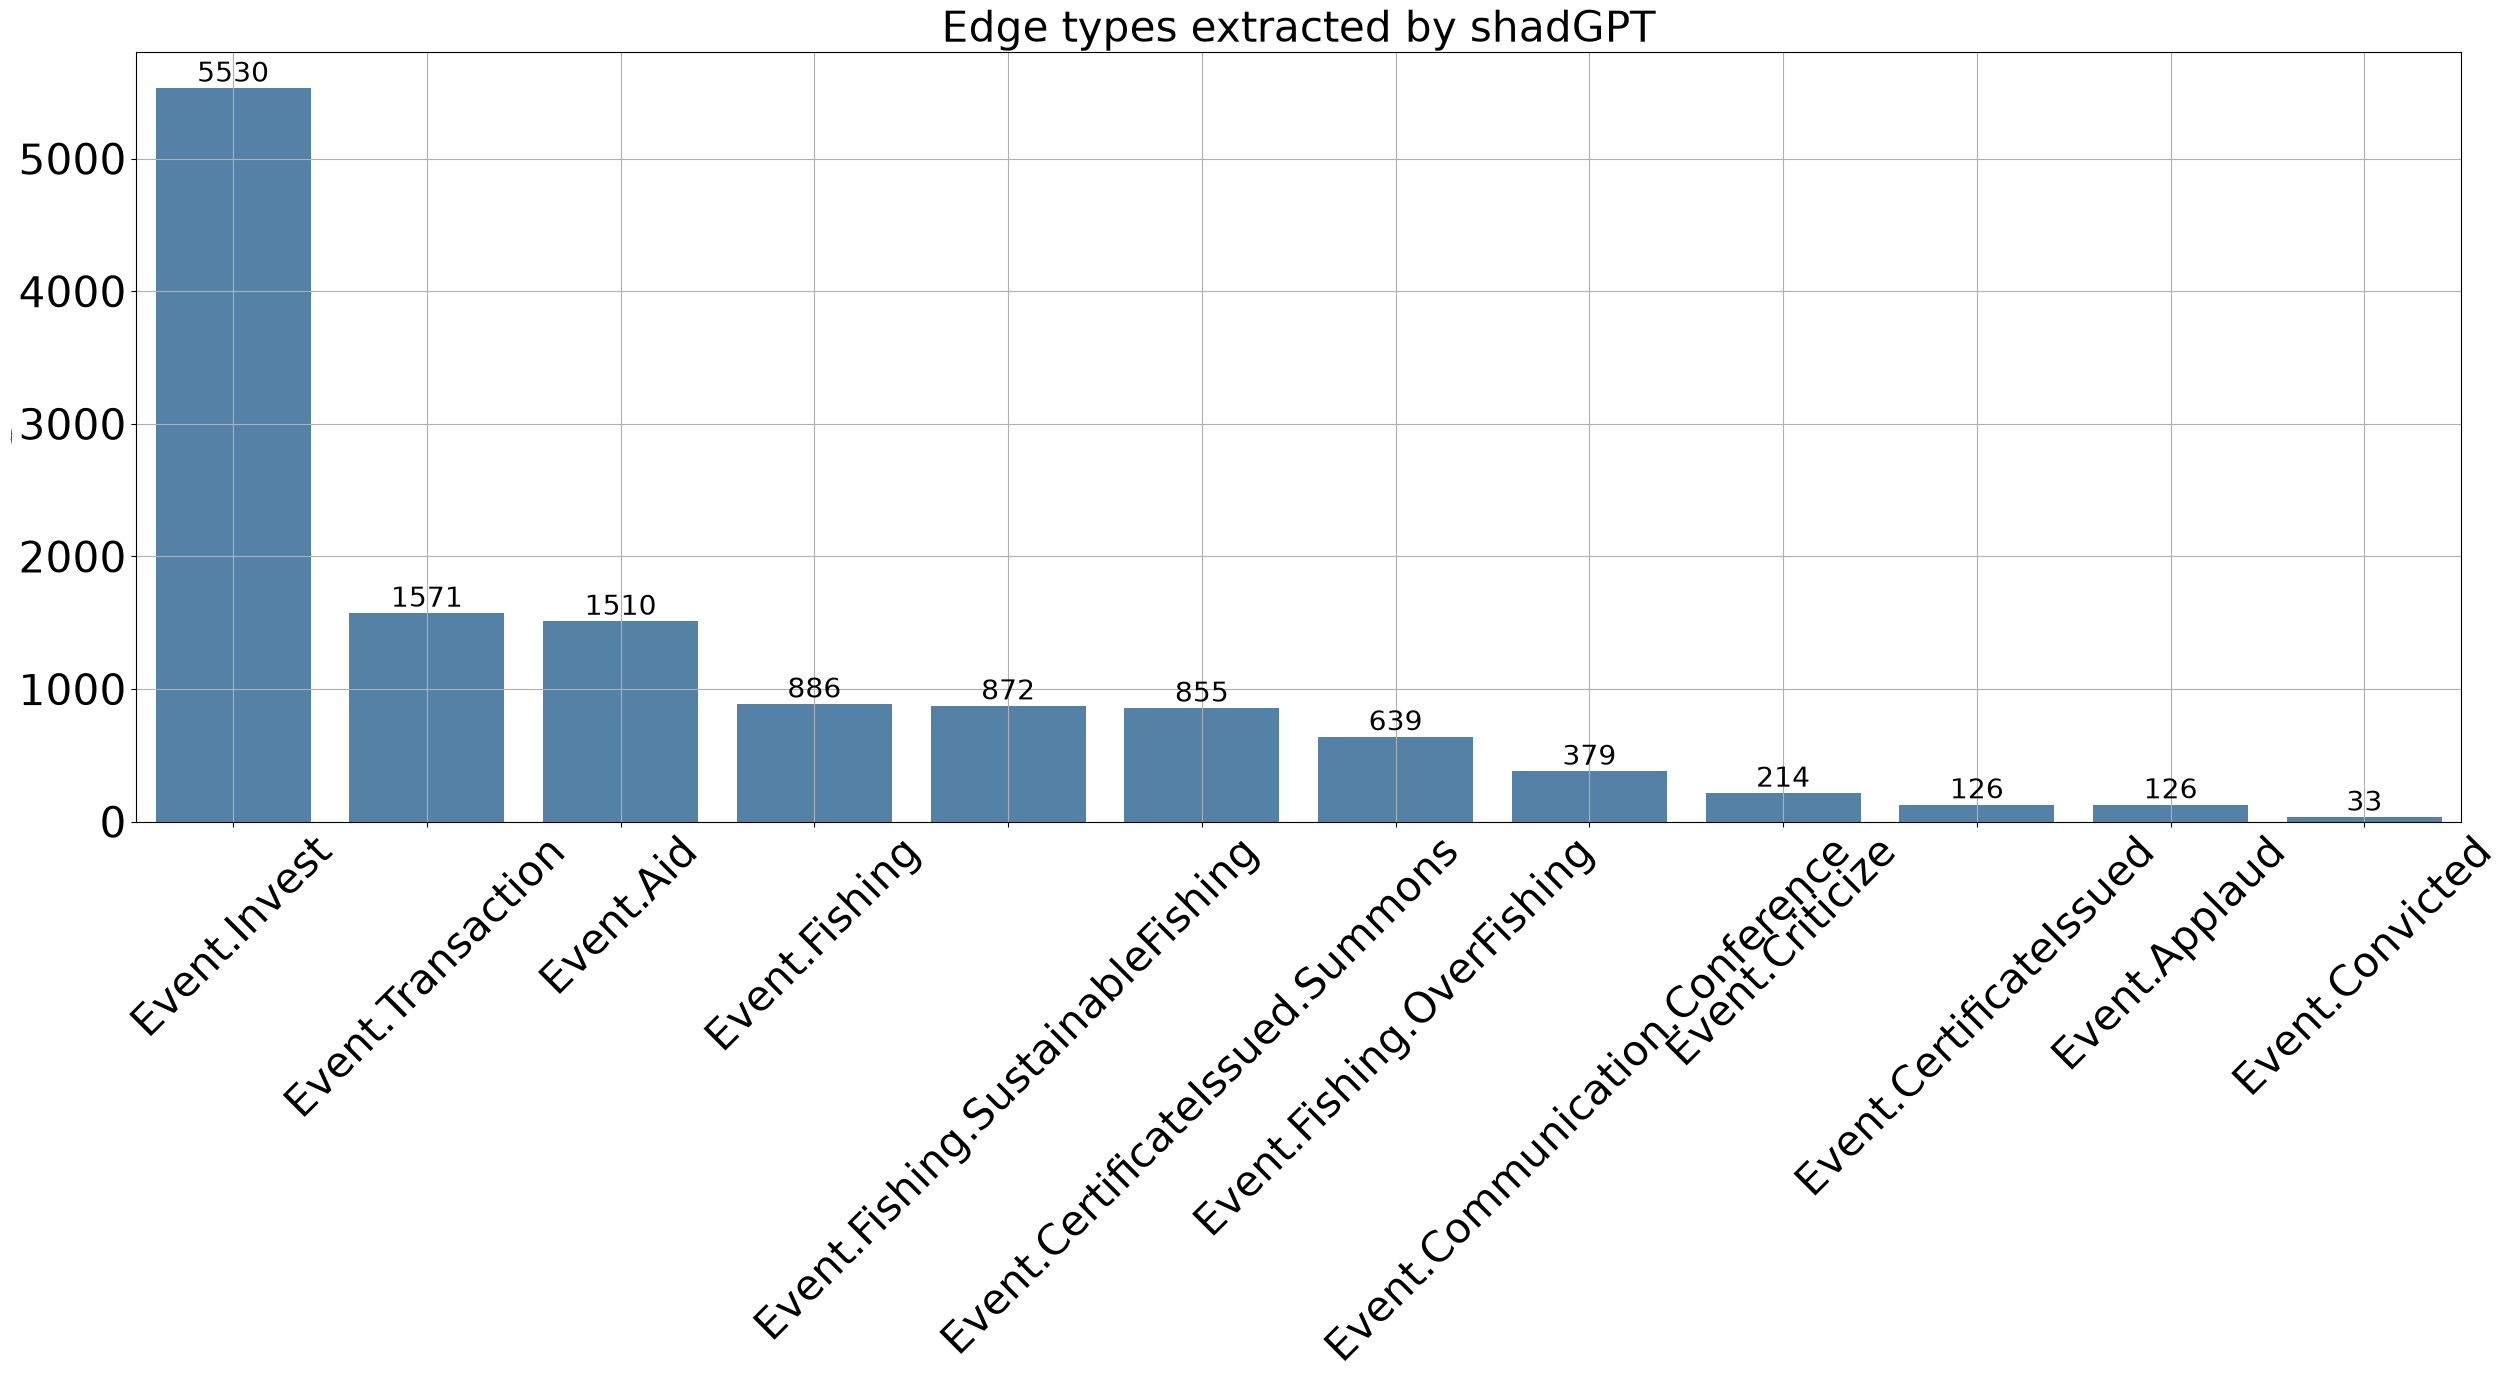

In [34]:
fig, ax = plt.subplots(figsize=(30,10), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = only_shadGPT["type"].value_counts().reset_index()
estado_df.sort_values(by="count", ascending=False, inplace=True)

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[0],
            y=estado_df.columns[1],
            ax=ax,
            color="steelblue",
            # order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Edge types extracted by shadGPT", fontsize=30)
sns_fig.set_ylabel(f"Number of comparisons", fontsize=0)
sns_fig.set_xlabel('', fontsize=20)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=45, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=30)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=20,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

plt.show()

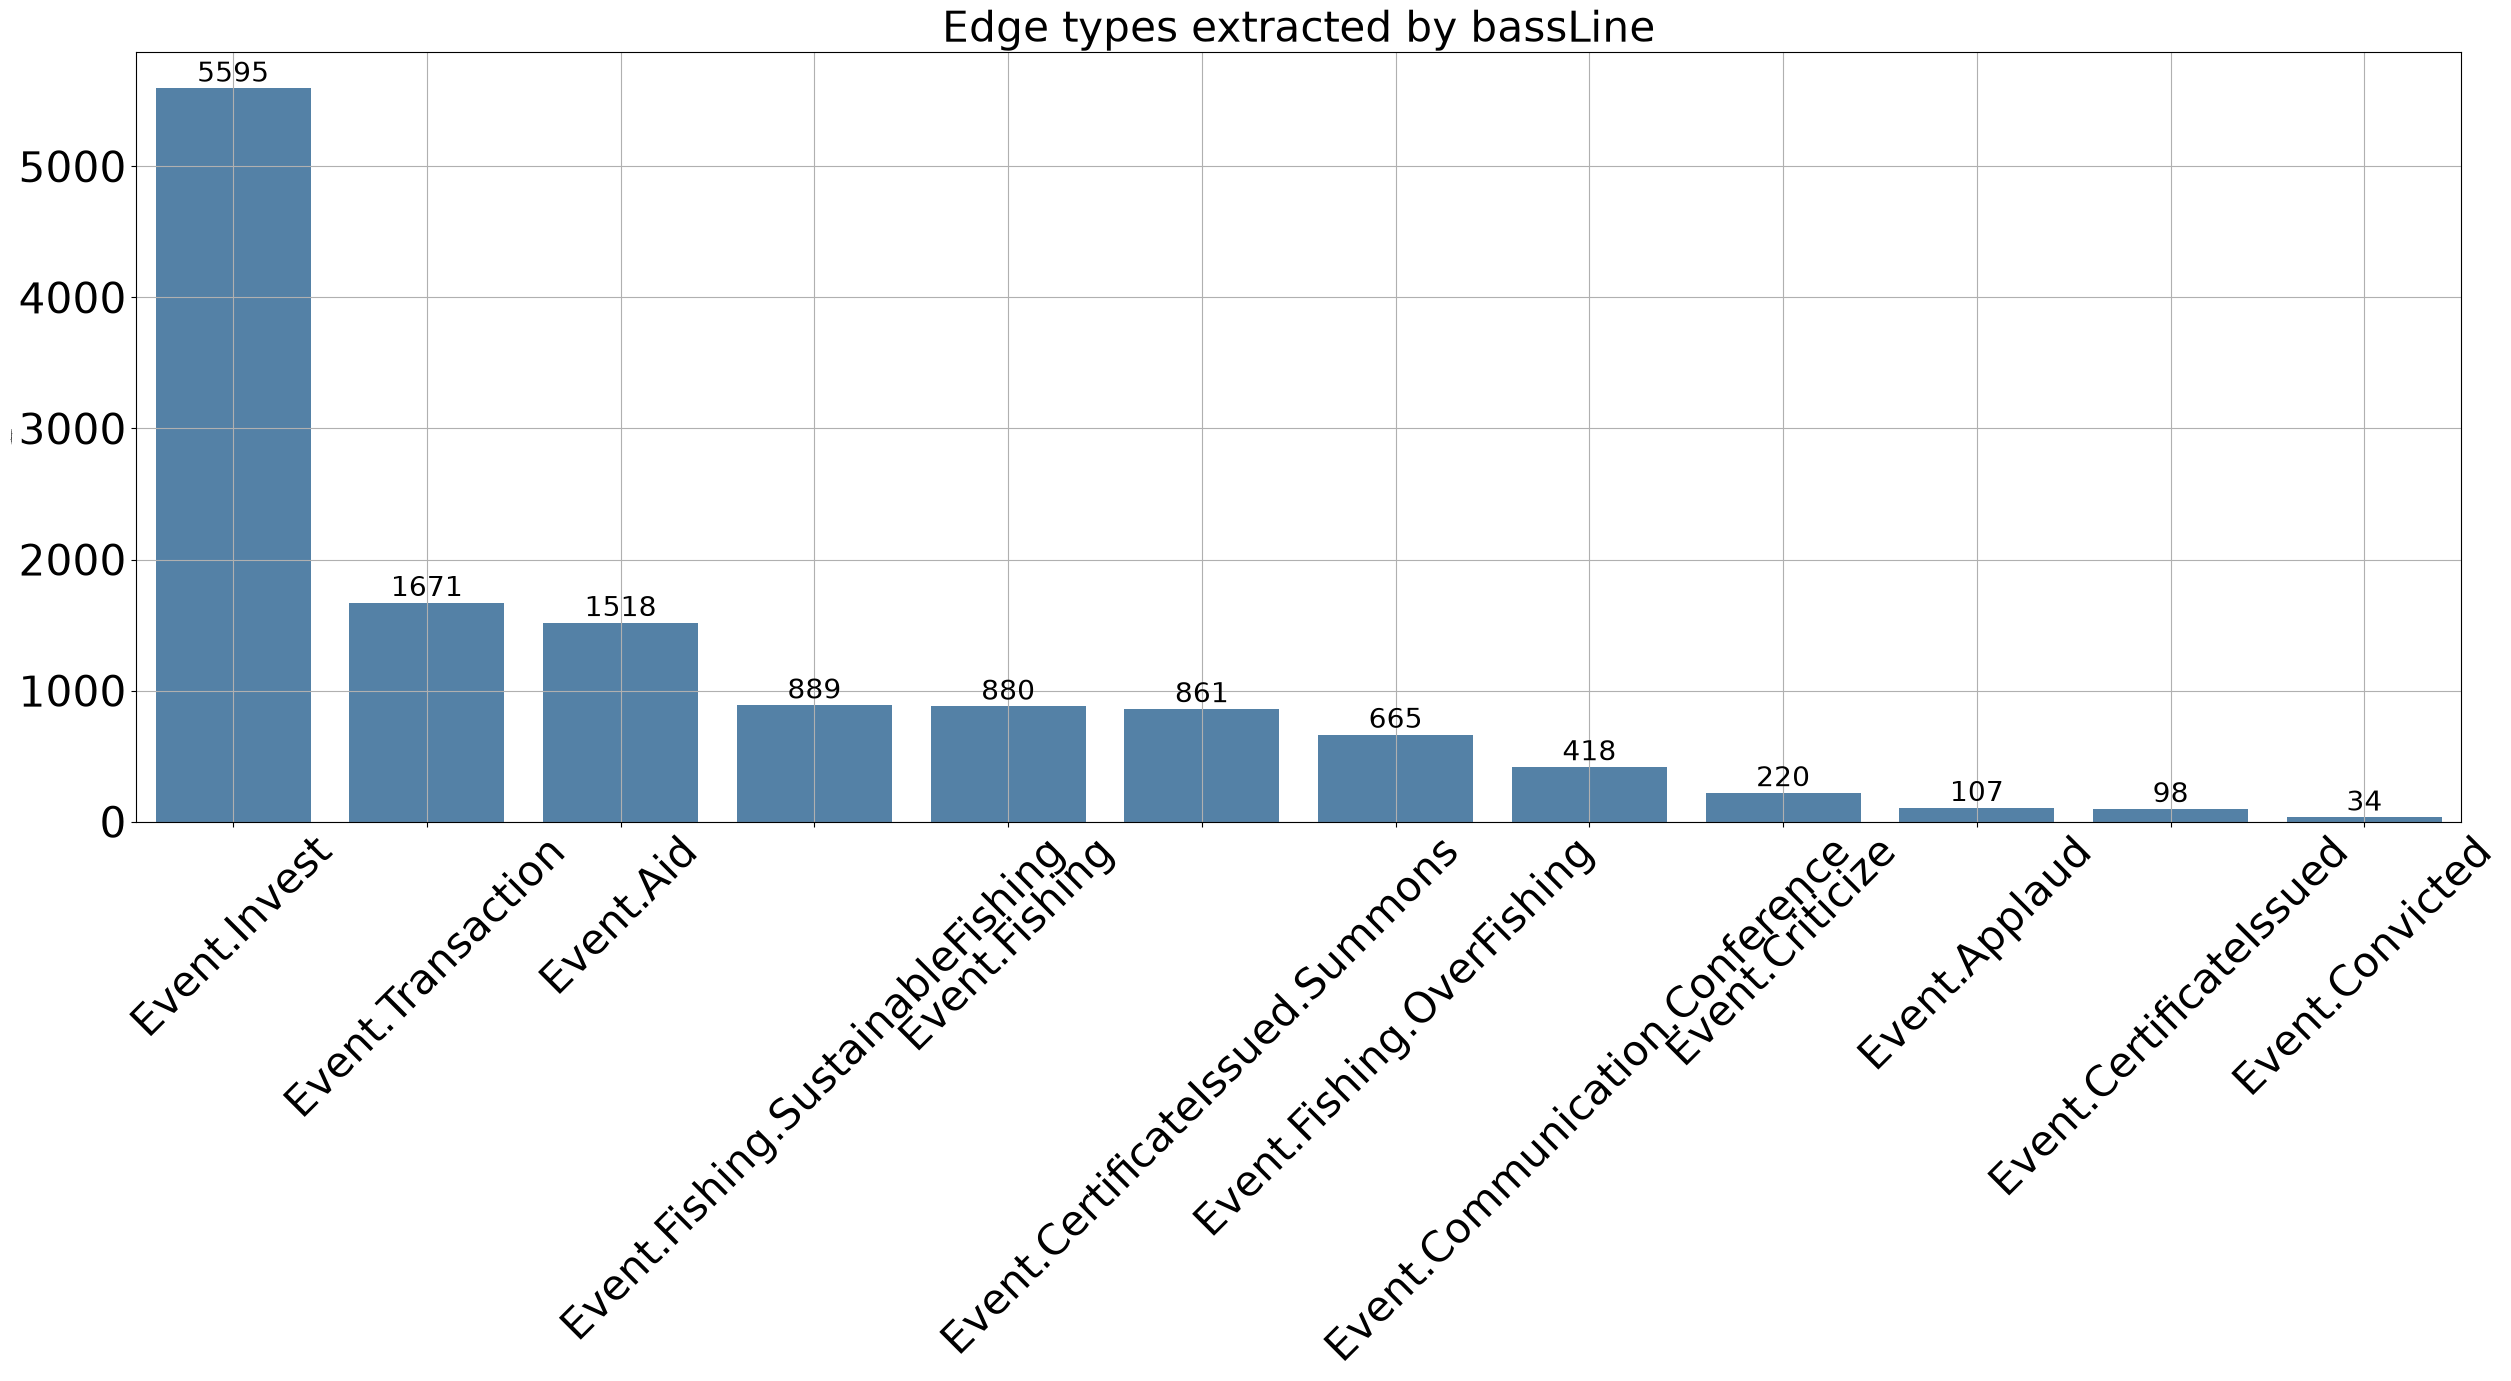

In [35]:
fig, ax = plt.subplots(figsize=(30,10), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = only_bassLine["type"].value_counts().reset_index()
estado_df.sort_values(by="count", ascending=False, inplace=True)

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[0],
            y=estado_df.columns[1],
            ax=ax,
            color="steelblue",
            # order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Edge types extracted by bassLine", fontsize=30)
sns_fig.set_ylabel(f"Number of comparisons", fontsize=0)
sns_fig.set_xlabel('', fontsize=20)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=45, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=30)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=20,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

plt.show()

### Sources

In [36]:
SOURCE_TYPE = df["source_type"].unique().tolist()
SOURCE_TYPE

['Entity.Organization.FishingCompany',
 'Entity.Organization.GovernmentOrg',
 'Entity.Organization.Company',
 'Entity.Organization.LogisticsCompany']

In [37]:
Goverments = df[df["source_type"]== 'Entity.Organization.GovernmentOrg']["source"].unique()

### Targets

In [38]:
SOURCE_TYPE = df["target_type"].unique().tolist()
SOURCE_TYPE

['Entity.Commodity',
 'Entity.Organization.FishingCompany',
 'Entity.Location.Region',
 'Entity.Organization',
 'Entity.Organization.Company',
 'Entity.Organization.NGO',
 'Entity.Organization.LogisticsCompany']

In [39]:
Comodities = df[df["target_type"]== 'Entity.Comodity']["target"].unique()
Locations = df[df["target_type"]== 'Entity.Location.Region']["target"].unique()
Organizations = df[df["target_type"]== 'Entity.Organization']["target"].unique()
NonGoverments = df[df["target_type"]== 'Entity.Organization.NGO']["target"].unique()
len(NonGoverments)

5

In [40]:
a = df[df["target_type"]== 'Entity.Organization.FishingCompany']["target"].unique()
b = df[df["source_type"]== 'Entity.Organization.FishingCompany']["source"].unique()
FishingCompanies = np.unique(np.concatenate((a, b)) ).tolist()
len(FishingCompanies)

100

In [41]:
a = df[df["target_type"]== 'Entity.Organization.LogisticsCompany']["target"].unique()
b = df[df["source_type"]== 'Entity.Organization.LogisticsCompany']["source"].unique()
LogisticCompanies = np.unique(np.concatenate((a, b)) ).tolist()
len(LogisticCompanies)

9

In [42]:
a = df[df["target_type"]== 'Entity.Organization.Company']["target"].unique()
b = df[df["source_type"]== 'Entity.Organization.Company']["source"].unique()
Companies = np.unique(np.concatenate((a, b)) ).tolist()
len(Companies)

67

### Edges

In [43]:
EDGE_TYPES = df["type"].unique().tolist()
EDGE_TYPES

['Event.Invest',
 'Event.CertificateIssued',
 'Event.Fishing',
 'Event.Applaud',
 'Event.Transaction',
 'Event.Communication.Conference',
 'Event.Aid',
 'Event.Fishing.SustainableFishing',
 'Event.Fishing.OverFishing',
 'Event.CertificateIssued.Summons',
 'Event.Criticize',
 'Event.Convicted']

### LLM-Search

In [44]:
ourGPT = pd.read_csv(f"{CSV_PATH}graph.csv", sep="\t", low_memory=False)
ourGPT = ourGPT[~ourGPT["target"].isna()].copy()
ourGPT = ourGPT[~ourGPT["source"].isna()].copy()
ourGPT = ourGPT[~ourGPT["type"].isna()].copy()
ourGPT["source"] = ourGPT["source"].apply(lambda x: x.lower())
ourGPT["type"] = ourGPT["type"].apply(lambda x: x.lower())
ourGPT["type"] = ourGPT["type"].apply(lambda x: ".".join([ c.capitalize() for c in x.split(".") ]) )
ourGPT["target"] = ourGPT["target"].apply(lambda x: x.lower())
ourGPT["new_type"] = df["type"].apply(lambda x: edge_category[x])
ourGPT

,source,type,target,context,_articleid,new_type
0,alvarez plc,Event.Aid,marine sanctuary,Aid to preserve vital ecosystems,Alvarez PLC__0__0__Haacklee Herald,Positive
1,alvarez plc,Event.Invest,efficiency,Strategic investments in efficiency and safety...,Alvarez PLC__0__0__Haacklee Herald,Positive
2,alvarez plc,Event.Invest,safety,Strategic investments in efficiency and safety...,Alvarez PLC__0__0__Haacklee Herald,Neutral
3,alvarez plc,Event.Invest,sustainable_nets,Development of sustainable nets,Alvarez PLC__0__0__Haacklee Herald,Positive
4,alvarez plc,Event.Invest,tracking_system,Development of tracking systems,Alvarez PLC__0__0__Haacklee Herald,Neutral
...,...,...,...,...,...,...
2815,york-castillo,Event.Transaction,cervantes-kramer,signed multiple fishing transactions with Cerv...,York-Castillo__0__0__The News Buoy,Neutral
2816,york-castillo,Event.Fishing,city of lomark,applauded for its commitment to sustainable an...,York-Castillo__0__0__The News Buoy,Positive
2817,york-castillo,Event.Fishing,city of south paackland,applauded for its commitment to sustainable an...,York-Castillo__0__0__The News Buoy,Positive
2818,york-castillo,Event.Certificateissued,city of lomark,"approved allowed to do fishing in Wrasse Beds,...",York-Castillo__0__0__The News Buoy,Positive


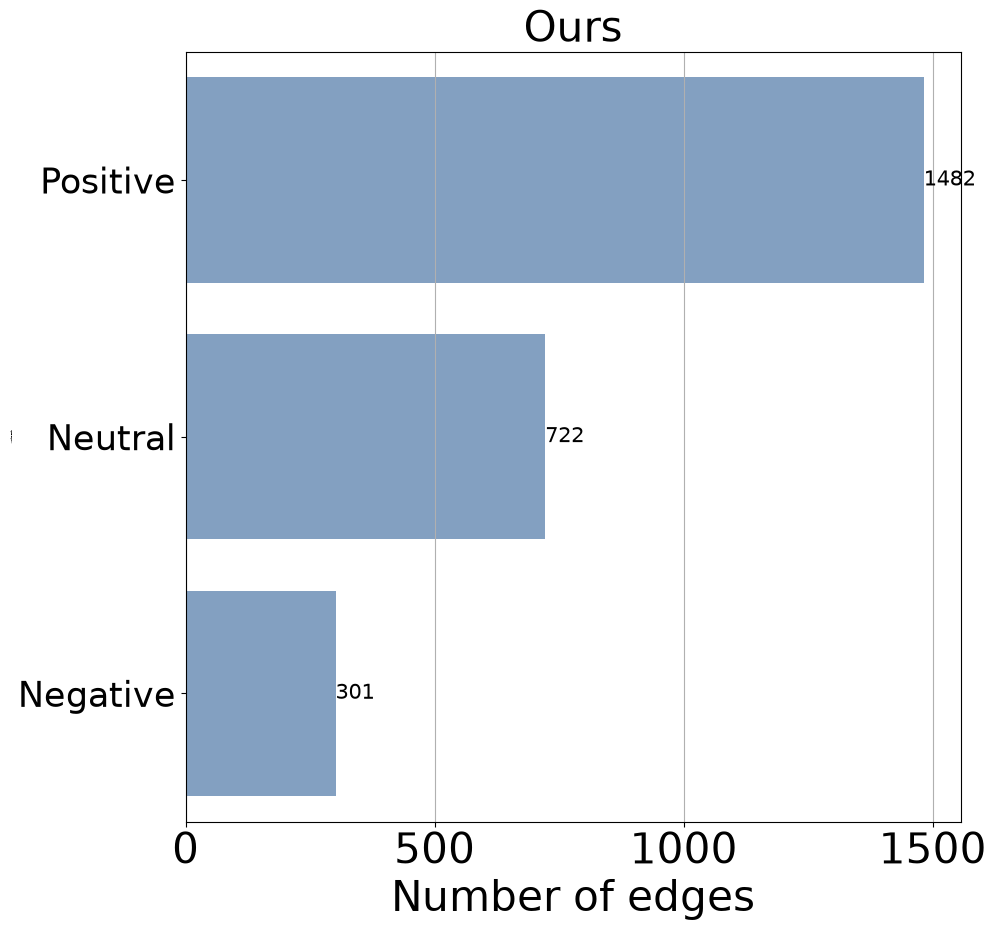

In [45]:
_, ax = plt.subplots(figsize=(10,10), nrows=1, ncols=1, sharex=False, sharey=False)

# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["new_type"].value_counts().reset_index()
data_df = ourGPT[ourGPT["type"].isin(EDGE_TYPES)]["new_type"].value_counts().reset_index()
# data_df.loc[(data_df["type"]=="Event.Invest"), "count"] +=313
# data_df[""]
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="#799fcb",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

sns_fig.set_title(f"Ours", fontsize=30)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'Number of edges', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

# ax.grid(True)
ax.xaxis.grid()

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

In [46]:
df[df["_articleid"]=="Alvarez PLC__0__0__Haacklee Herald"]

,source,source_type,type,weight,target,target_type,_last_edited_by,_last_edited_date,_date_added,_date,_raw_source,_algorithm,_articleid,new_type
2634,alvarez plc,Entity.Organization.FishingCompany,Event.Transaction,0,cuevas plc,Entity.Organization.FishingCompany,Olokun Daramola,2035-02-27,2035-02-27,2035-02-27,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Neutral
2636,alvarez plc,Entity.Organization.FishingCompany,Event.Invest,1,tracking_system,Entity.Commodity,Olokun Daramola,2035-02-27,2035-02-27,2035-02-27,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive
2638,alvarez plc,Entity.Organization.FishingCompany,Event.Aid,1,marine_sanctuary,Entity.Organization,Olokun Daramola,2035-02-27,2035-02-27,2035-02-27,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive
2639,city of himark,Entity.Organization.GovernmentOrg,Event.CertificateIssued,1,alvarez plc,Entity.Organization.FishingCompany,Olokun Daramola,2035-02-27,2035-02-27,2035-02-27,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive
2642,city of centralia,Entity.Organization.GovernmentOrg,Event.CertificateIssued,1,alvarez plc,Entity.Organization.FishingCompany,Olokun Daramola,2035-02-27,2035-02-27,2035-02-27,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive
2649,alvarez plc,Entity.Organization.FishingCompany,Event.Invest,1,sustainable_nets,Entity.Commodity,Olokun Daramola,2035-02-27,2035-02-27,2035-02-27,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive
2650,alvarez plc,Entity.Organization.FishingCompany,Event.Invest,1,efficiency,Entity.Commodity,Olokun Daramola,2035-02-27,2035-02-27,2035-02-27,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive
3024,alvarez plc,Entity.Organization.FishingCompany,Event.Invest,1,sustainable_nets,Entity.Commodity,Olokun Daramola,2035-03-04,2035-03-04,2035-03-04,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive
3025,alvarez plc,Entity.Organization.FishingCompany,Event.Communication.Conference,1,franco-stuart,Entity.Organization.FishingCompany,Olokun Daramola,2035-03-04,2035-03-04,2035-03-04,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive
3026,alvarez plc,Entity.Organization.FishingCompany,Event.Invest,1,tracking_system,Entity.Commodity,Olokun Daramola,2035-03-04,2035-03-04,2035-03-04,Haacklee Herald,BassLine,Alvarez PLC__0__0__Haacklee Herald,Positive


In [47]:
ourGPT["source_len"] = ourGPT["source"].apply(lambda x: len(x))
ourGPT["target_len"] = ourGPT["target"].apply(lambda x: len(x))
ourGPT = ourGPT[ (ourGPT["source_len"]>1) & (ourGPT["target_len"]>1) ].copy()
ourGPT["source_type"] = ourGPT["source"].apply(lambda x: source_map[x] if x in source_map.keys() else np.nan)
ourGPT["target_type"] = ourGPT["target"].apply(lambda x: target_map[x] if x in target_map.keys() else np.nan)
ourGPT

,source,type,target,context,_articleid,new_type,source_len,target_len,source_type,target_type
0,alvarez plc,Event.Aid,marine sanctuary,Aid to preserve vital ecosystems,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,NaN
1,alvarez plc,Event.Invest,efficiency,Strategic investments in efficiency and safety...,Alvarez PLC__0__0__Haacklee Herald,Positive,11,10,Entity.Organization.FishingCompany,Entity.Commodity
2,alvarez plc,Event.Invest,safety,Strategic investments in efficiency and safety...,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,6,Entity.Organization.FishingCompany,Entity.Commodity
3,alvarez plc,Event.Invest,sustainable_nets,Development of sustainable nets,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,Entity.Commodity
4,alvarez plc,Event.Invest,tracking_system,Development of tracking systems,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,15,Entity.Organization.FishingCompany,Entity.Commodity
...,...,...,...,...,...,...,...,...,...,...
2815,york-castillo,Event.Transaction,cervantes-kramer,signed multiple fishing transactions with Cerv...,York-Castillo__0__0__The News Buoy,Neutral,13,16,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany
2816,york-castillo,Event.Fishing,city of lomark,applauded for its commitment to sustainable an...,York-Castillo__0__0__The News Buoy,Positive,13,14,Entity.Organization.FishingCompany,NaN
2817,york-castillo,Event.Fishing,city of south paackland,applauded for its commitment to sustainable an...,York-Castillo__0__0__The News Buoy,Positive,13,23,Entity.Organization.FishingCompany,NaN
2818,york-castillo,Event.Certificateissued,city of lomark,"approved allowed to do fishing in Wrasse Beds,...",York-Castillo__0__0__The News Buoy,Positive,13,14,Entity.Organization.FishingCompany,NaN


#### Distance

In [48]:
# !pip install python-Levenshtein

In [49]:
import Levenshtein

def find_closest_string(query, choices):
    closest_match = None
    smallest_distance = float('inf')

    for choice in choices:
        distance = Levenshtein.distance(query, choice)
        if distance < smallest_distance:
            smallest_distance = distance
            closest_match = choice

    return closest_match, smallest_distance

In [50]:
sources = df["source"].unique()
targets = df["target"].unique()
len(sources), len(targets)

(126, 192)

In [51]:
find_closest_string("alvarez plc", sources)

('alvarez plc', 0)

In [52]:
ourGPT["close_source_name"] = ourGPT["source"].apply(lambda x: find_closest_string(x, sources)[0])
ourGPT["close_target_name"] = ourGPT["target"].apply(lambda x: find_closest_string(x, targets)[0])
ourGPT["close_source_score"] = ourGPT["source"].apply(lambda x: find_closest_string(x, sources)[1])
ourGPT["close_target_score"] = ourGPT["target"].apply(lambda x: find_closest_string(x, targets)[1])

In [53]:
print(ourGPT["close_source_score"].value_counts())
print(ourGPT["close_target_score"].value_counts())

close_source_score
0     2557
1      188
16      17
14      10
7        8
15       8
13       7
4        6
9        2
10       2
20       2
18       2
8        1
12       1
11       1
3        1
5        1
Name: count, dtype: int64
close_target_score
0      1815
1       247
8       105
12       84
11       71
7        69
10       56
5        40
4        39
15       36
6        29
2        25
16       19
17       18
14       17
22       14
20       13
18       12
13       12
32       10
9         9
23        8
21        7
25        6
24        5
29        4
26        3
3         3
19        3
28        2
35        2
46        2
42        2
52        2
27        2
43        2
31        2
72        2
41        2
47        1
68        1
65        1
39        1
60        1
50        1
34        1
44        1
45        1
30        1
36        1
81        1
84        1
372       1
38        1
Name: count, dtype: int64


In [54]:
ourGPT['source'] = ourGPT.apply(lambda row: row['close_source_name'] if row["close_source_score"]<=1 else row['source'], axis=1)
ourGPT['target'] = ourGPT.apply(lambda row: row['close_target_name'] if row["close_target_score"]<=1 else row['target'], axis=1)

In [55]:
ourGPT

,source,type,target,context,_articleid,new_type,source_len,target_len,source_type,target_type,close_source_name,close_target_name,close_source_score,close_target_score
0,alvarez plc,Event.Aid,marine_sanctuary,Aid to preserve vital ecosystems,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,NaN,alvarez plc,marine_sanctuary,0,1
1,alvarez plc,Event.Invest,efficiency,Strategic investments in efficiency and safety...,Alvarez PLC__0__0__Haacklee Herald,Positive,11,10,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,efficiency,0,0
2,alvarez plc,Event.Invest,safety,Strategic investments in efficiency and safety...,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,6,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,safety,0,0
3,alvarez plc,Event.Invest,sustainable_nets,Development of sustainable nets,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,sustainable_nets,0,0
4,alvarez plc,Event.Invest,tracking_system,Development of tracking systems,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,15,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,tracking_system,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2815,york-castillo,Event.Transaction,cervantes-kramer,signed multiple fishing transactions with Cerv...,York-Castillo__0__0__The News Buoy,Neutral,13,16,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,york-castillo,cervantes-kramer,0,0
2816,york-castillo,Event.Fishing,city of lomark,applauded for its commitment to sustainable an...,York-Castillo__0__0__The News Buoy,Positive,13,14,Entity.Organization.FishingCompany,NaN,york-castillo,hughes-clark,0,10
2817,york-castillo,Event.Fishing,city of south paackland,applauded for its commitment to sustainable an...,York-Castillo__0__0__The News Buoy,Positive,13,23,Entity.Organization.FishingCompany,NaN,york-castillo,thompson-padilla,0,15
2818,york-castillo,Event.Certificateissued,city of lomark,"approved allowed to do fishing in Wrasse Beds,...",York-Castillo__0__0__The News Buoy,Positive,13,14,Entity.Organization.FishingCompany,NaN,york-castillo,hughes-clark,0,10


In [56]:
ourGPT_nodes = set( set( ourGPT["source"].unique() ).union( set(ourGPT["target"].unique()) ) )
len(ourGPT_nodes), ourGPT_nodes

(479,
 {'a concerned citizen',
  'acquiring more vessels',
  'adaptation',
  'advanced tracking systems and sustainable nets',
  'allen-',
  'allen-weiss',
  'alvarez plc',
  'anderson, brown and green',
  'anderson-brown and green',
  'arawakfish cargo ges.m.b.h.',
  'archer-johnson',
  'arell',
  'arellano group',
  'attendees',
  'baringoamerica marine ges.m.b.h.',
  'barnes and sons',
  'barnes and sons, murray, friedman and wall',
  'barnett ltd',
  'barnett ltd conference',
  'bates',
  'bates-anderson',
  'bell, reynolds and forbes',
  'bishop-hernandez',
  'blackwell, clark and lam',
  'blackwell-clark and lam',
  'bowers group',
  'brown, clarke and martinez',
  'brown-stokes',
  'bryant, macdonald and howard',
  'burns inc',
  'cain, simpson and hernandez',
  'castillo-elliott',
  'centralia',
  'ceo and president',
  'ceo erick walker, cfo james myers, and general counsel sarah rivera',
  'cervantes-kramer',
  'challenges',
  'chapman, hall and miller',
  'chavez, anderson a

In [57]:
len(bassLine_nodes - ourGPT_nodes), bassLine_nodes - ourGPT_nodes

(27,
 {'6. america transit plc',
  'agualeska transit n.v.',
  'bailey-mccullough',
  'dutch bill america line ab',
  'flounderleska marine bv',
  'gvardeyskamerica shipping plc',
  'hartman group',
  'homabaymarine carriers n.v.',
  'kareliansleska holdings ojsc',
  'may and sons',
  'namriver transit a/s',
  'nemo reef',
  'northeastseafood carriers',
  'oka charter boat transport ojsc',
  'oranjestadcreek express sagl',
  'raymond llc',
  'samakadredgetransport ojsc',
  'scaniaseafood holdings ltd. liability co',
  'southleska worldwide as',
  'southseafood express corp',
  'sparmans marine carriers oyj',
  'stichtingmarine shipping company',
  'sumacamerica transport gmbh & co. kg',
  'tainamarine fishing co',
  'v. miesel shipping',
  'vargas ltd',
  'westriver shipping kgaa'})

In [58]:
len(shadGPT_nodes - ourGPT_nodes), shadGPT_nodes - ourGPT_nodes

(27,
 {'6. america transit plc',
  'agualeska transit n.v.',
  'bailey-mccullough',
  'dutch bill america line ab',
  'flounderleska marine bv',
  'gvardeyskamerica shipping plc',
  'hartman group',
  'homabaymarine carriers n.v.',
  'irtysh creek logistics inc',
  'kareliansleska holdings ojsc',
  'may and sons',
  'namriver transit a/s',
  'nemo reef',
  'northeastseafood carriers',
  'oka charter boat transport ojsc',
  'oranjestadcreek express sagl',
  'raymond llc',
  'samakadredgetransport ojsc',
  'scaniaseafood holdings ltd. liability co',
  'southleska worldwide as',
  'sparmans marine carriers oyj',
  'stichtingmarine shipping company',
  'sumacamerica transport gmbh & co. kg',
  'tainamarine fishing co',
  'v. miesel shipping',
  'vargas ltd',
  'westriver shipping kgaa'})

In [59]:
ourGPT.to_csv(f"{CSV_PATH}graph_modified.csv", sep="\t", index=False)

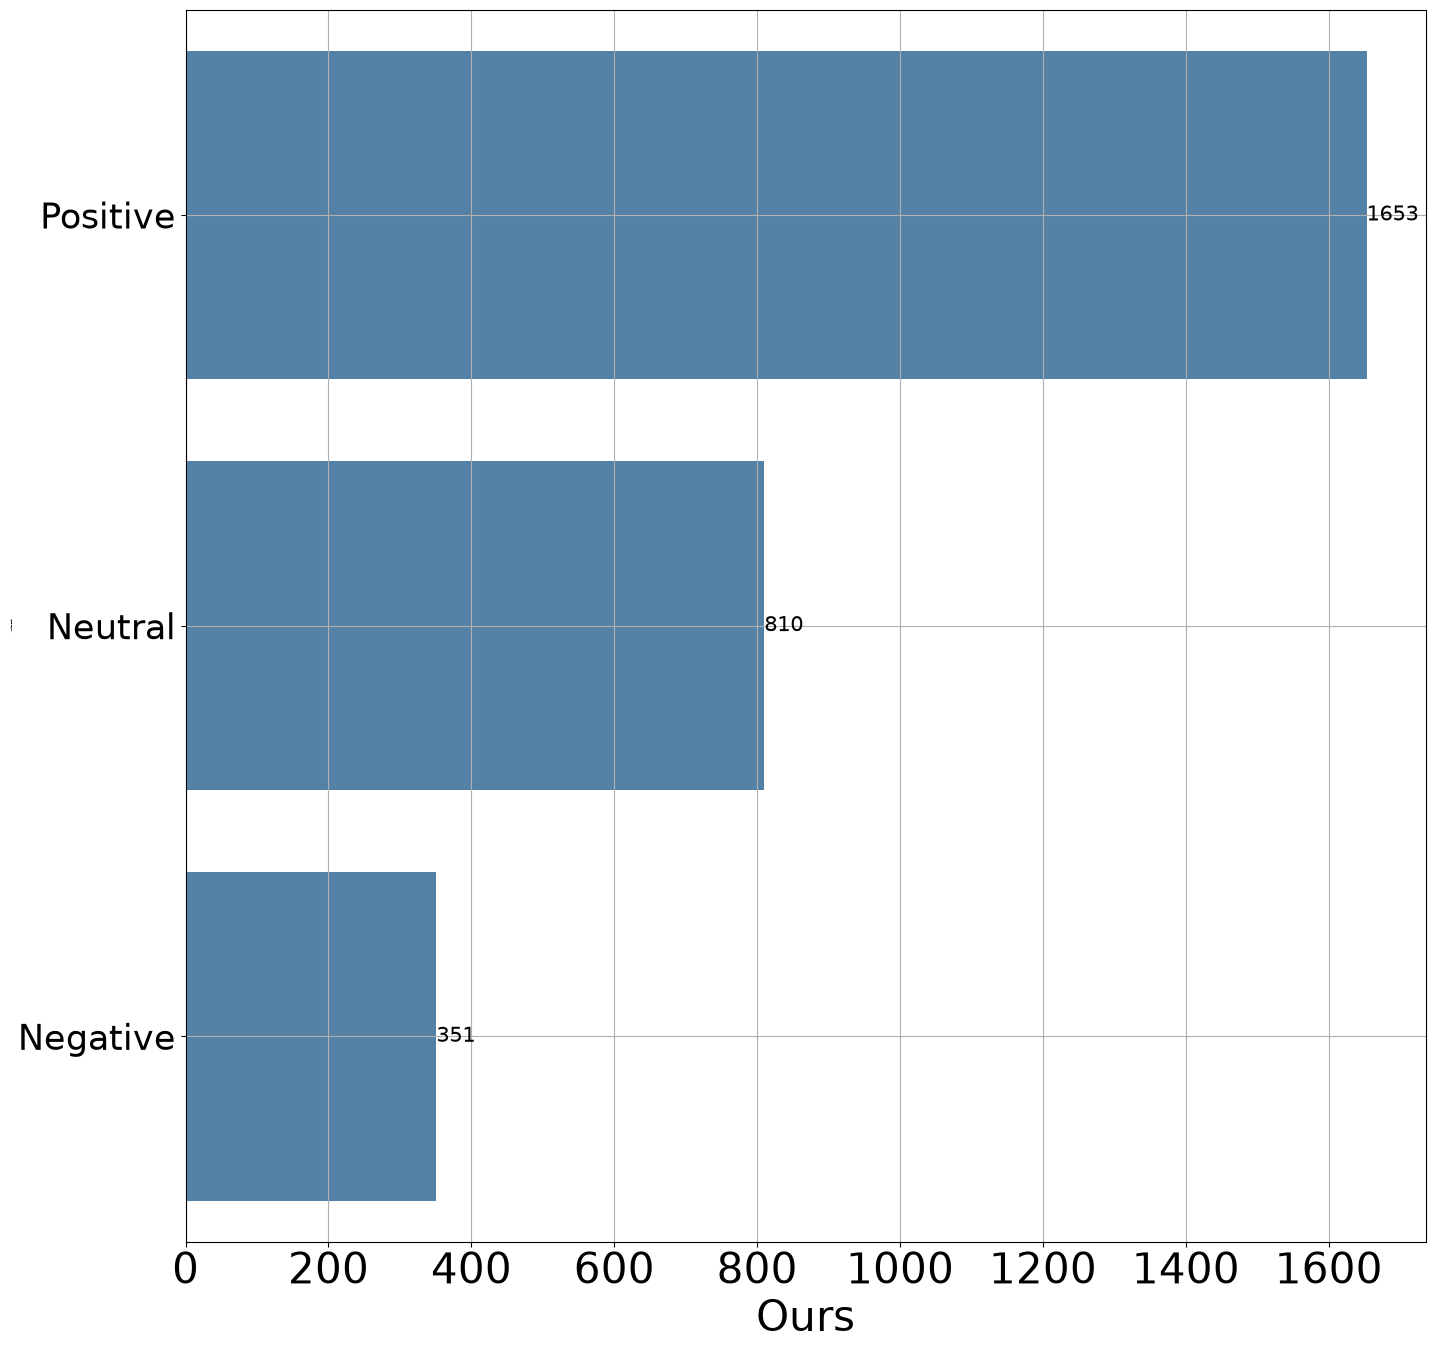

In [60]:
algorithm_name="ShadGPT"
_, ax = plt.subplots(figsize=(16,16), nrows=1, ncols=1, sharex=False, sharey=False)

data_df = ourGPT["new_type"].value_counts().reset_index()
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="steelblue",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

#sns_fig.set_title(f"Number of CVE-IDs cited per user, Total: {user_cve_sum}, Avg: {user_cve_mean}", fontsize=16)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'Ours', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

ax.grid(True)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

#### Comparing

In [61]:
allthree = pd.merge(ourGPT, both, on=["source", "type", "target", "_articleid"], how='inner')
allthree

,source,type,target,context,_articleid,new_type,source_len,target_len,source_type,target_type,close_source_name,close_target_name,close_source_score,close_target_score,_merge
0,alvarez plc,Event.Aid,marine_sanctuary,Aid to preserve vital ecosystems,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,NaN,alvarez plc,marine_sanctuary,0,1,both
1,alvarez plc,Event.Invest,efficiency,Strategic investments in efficiency and safety...,Alvarez PLC__0__0__Haacklee Herald,Positive,11,10,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,efficiency,0,0,both
2,alvarez plc,Event.Invest,safety,Strategic investments in efficiency and safety...,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,6,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,safety,0,0,both
3,alvarez plc,Event.Invest,sustainable_nets,Development of sustainable nets,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,sustainable_nets,0,0,both
4,alvarez plc,Event.Invest,tracking_system,Development of tracking systems,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,15,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,tracking_system,0,0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,wu-hart,Event.Aid,marine_sanctuary,Contributions to marine sanctuary aid,Wu-Hart__0__0__Lomark Daily,Positive,7,16,Entity.Organization.FishingCompany,NaN,wu-hart,marine_sanctuary,0,1,both
325,wu-hart,Event.Invest,tracking_system,Investments in tracking systems,Wu-Hart__0__0__Lomark Daily,Positive,7,15,Entity.Organization.FishingCompany,NaN,wu-hart,tracking_system,0,1,both
326,wu-hart,Event.Aid,marine_sanctuary,Further support for marine sanctuary aid,Wu-Hart__0__0__Lomark Daily,Positive,7,16,Entity.Organization.FishingCompany,NaN,wu-hart,marine_sanctuary,0,1,both
327,wu-hart,Event.Invest,safety,Investments in safety,Wu-Hart__0__0__Lomark Daily,Negative,7,6,Entity.Organization.FishingCompany,Entity.Commodity,wu-hart,safety,0,0,both


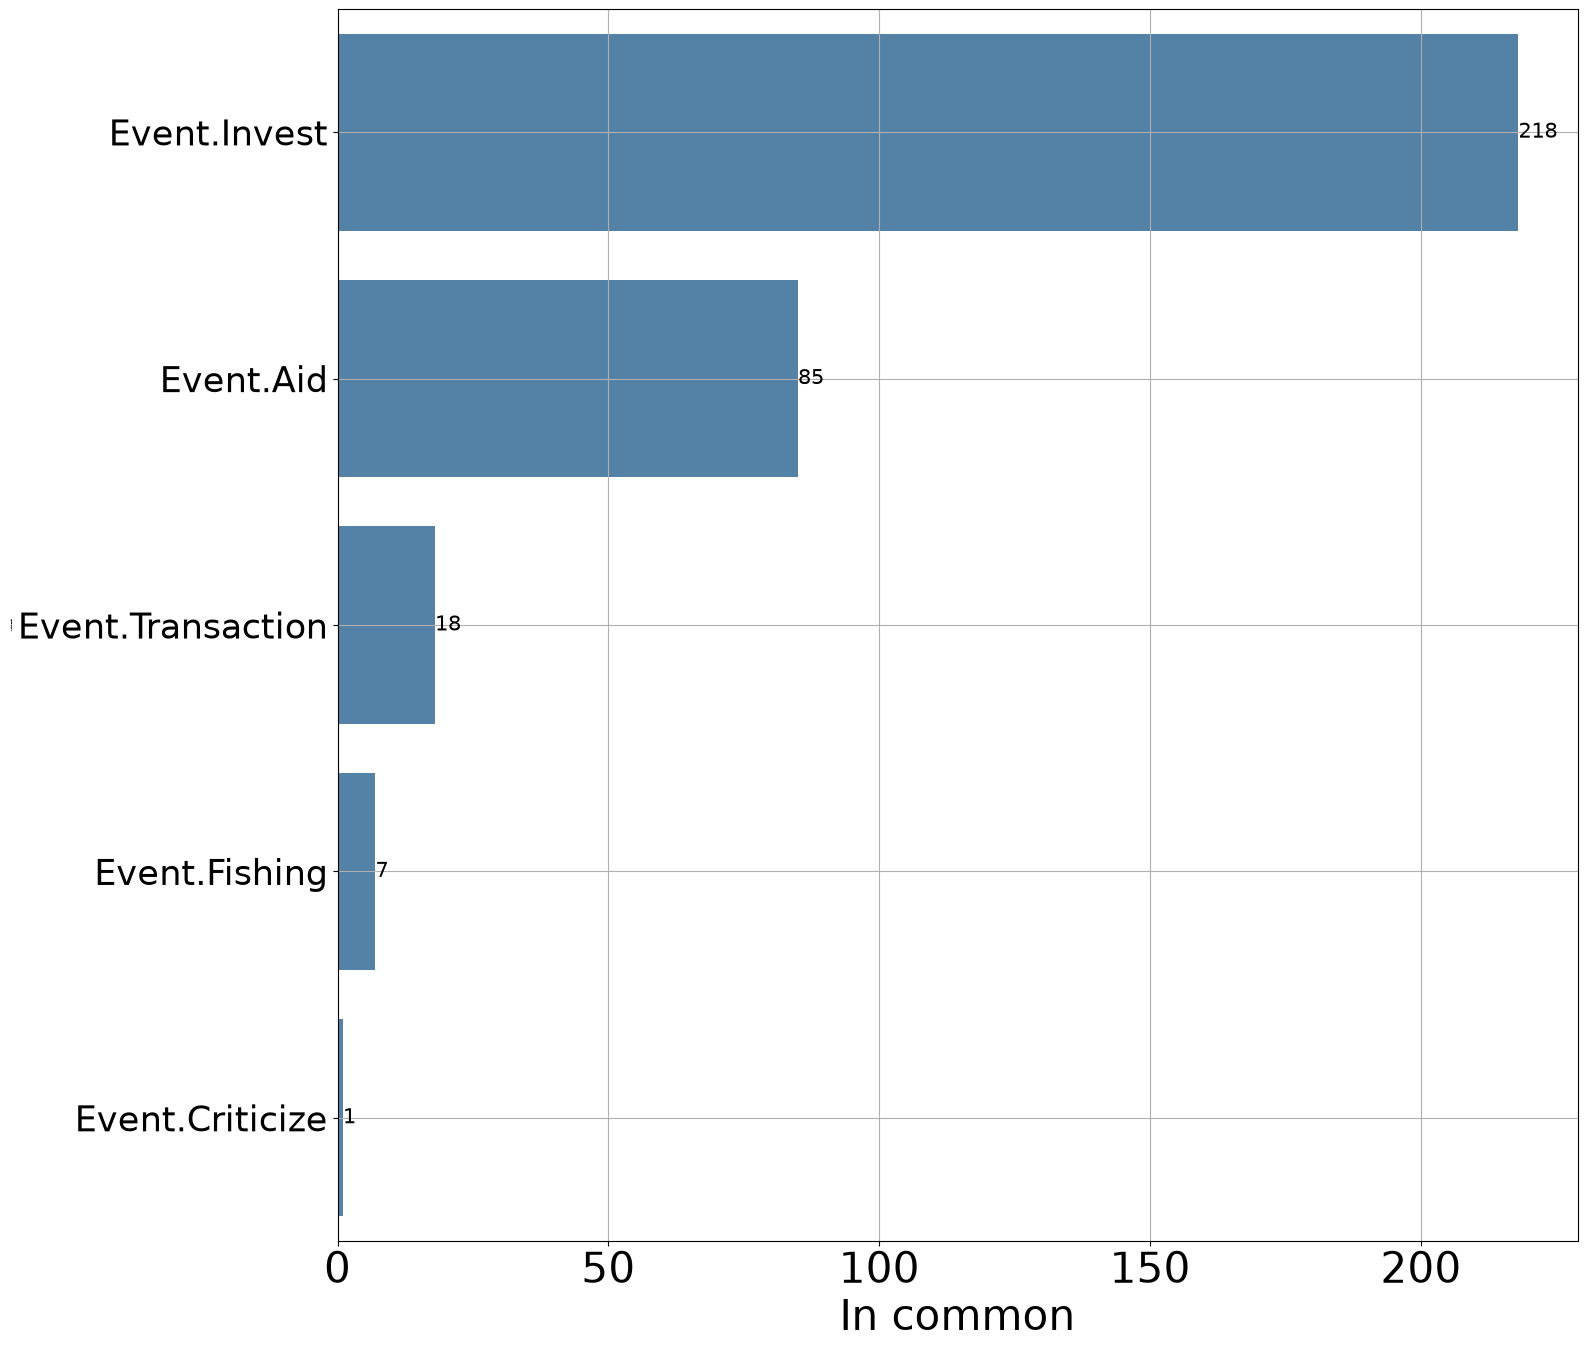

In [62]:
algorithm_name="ShadGPT"
_, ax = plt.subplots(figsize=(16,16), nrows=1, ncols=1, sharex=False, sharey=False)

data_df = allthree["type"].value_counts().reset_index()
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="steelblue",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

#sns_fig.set_title(f"Number of CVE-IDs cited per user, Total: {user_cve_sum}, Avg: {user_cve_mean}", fontsize=16)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'In common', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

ax.grid(True)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

#### Ours vs BassLine

In [63]:
ourGPT_and_bassLine = pd.merge(ourGPT, bassLine, on=["source", "type", "target", "_articleid"], how='inner', indicator=True)
ourGPT_and_bassLine[ ourGPT_and_bassLine["_merge"]=="both" ].sort_values(by="_articleid")

,source,type,target,context,_articleid,new_type,source_len,target_len,source_type,target_type,close_source_name,close_target_name,close_source_score,close_target_score,_date_added,_last_edited_date,_last_edited_by,_merge
0,alvarez plc,Event.Aid,marine_sanctuary,Aid to preserve vital ecosystems,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,NaN,alvarez plc,marine_sanctuary,0,1,2035-02-27,2035-02-27,Olokun Daramola,both
17,alvarez plc,Event.Aid,marine_sanctuary,Actively supported marine sanctuary initiatives,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,NaN,alvarez plc,marine_sanctuary,0,1,2035-06-28,2035-06-28,Kristin Baker,both
16,alvarez plc,Event.Aid,marine_sanctuary,Actively supported marine sanctuary initiatives,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,NaN,alvarez plc,marine_sanctuary,0,1,2035-02-27,2035-02-27,Olokun Daramola,both
15,alvarez plc,Event.Communication.Conference,franco-stuart,Participation in conferences alongside industr...,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,13,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,alvarez plc,franco-stuart,0,0,2035-03-04,2035-03-04,Olokun Daramola,both
14,alvarez plc,Event.Invest,tracking_system,Development of tracking systems,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,15,Entity.Organization.FishingCompany,Entity.Commodity,alvarez plc,tracking_system,0,0,2035-07-19,2035-07-19,Junior Shurdlu,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1354,york-castillo,Event.Transaction,payne group,signed multiple transactions with companies,York-Castillo__0__0__Haacklee Herald,Neutral,13,11,Entity.Organization.FishingCompany,Entity.Organization.Company,york-castillo,payne group,0,0,2035-04-03,2035-04-03,Worf Peer,both
1356,york-castillo,Event.Transaction,lee-smith,signed multiple transactions with companies,York-Castillo__0__0__Haacklee Herald,Positive,13,9,Entity.Organization.FishingCompany,Entity.Organization.Company,york-castillo,lee-smith,0,0,2035-04-03,2035-04-03,Worf Peer,both
1358,york-castillo,Event.Aid,marine_sanctuary,"has given $10,000 to a local marine sanctuary ...",York-Castillo__0__0__Lomark Daily,Positive,13,16,Entity.Organization.FishingCompany,NaN,york-castillo,marine_sanctuary,0,1,2035-07-06,2035-07-06,Pelagia Alethea Mordoch,both
1357,york-castillo,Event.Aid,marine_sanctuary,"has given $10,000 to a local marine sanctuary ...",York-Castillo__0__0__Lomark Daily,Positive,13,16,Entity.Organization.FishingCompany,NaN,york-castillo,marine_sanctuary,0,1,2035-04-03,2035-04-03,Melinda Manning,both


In [64]:
ourGPT_diff_bassLine = pd.merge(ourGPT, bassLine, on=["source", "type", "target", "_articleid"], how='left', indicator=True)
ourGPT_diff_bassLine[ ourGPT_diff_bassLine["_merge"]=="left_only" ].sort_values(by="_articleid")

,source,type,target,context,_articleid,new_type,source_len,target_len,source_type,target_type,close_source_name,close_target_name,close_source_score,close_target_score,_date_added,_last_edited_date,_last_edited_by,_merge
15,alvarez plc,Event.Communication.Conference,"clements, allen and sullivan",Participation in conferences alongside industr...,Alvarez PLC__0__0__Haacklee Herald,Positive,11,28,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,alvarez plc,"clements, allen and sullivan",0,0,NaN,NaN,NaN,left_only
20,alvarez plc,Event.Transaction,barnett ltd,Collaborations and transactions,Alvarez PLC__0__0__Haacklee Herald,Positive,11,11,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,alvarez plc,barnett ltd,0,0,NaN,NaN,NaN,left_only
21,alvarez plc,Event.Transaction,"cain, simpson and hernandez",Collaborations and transactions,Alvarez PLC__0__0__Haacklee Herald,Positive,11,28,Entity.Organization.FishingCompany,NaN,alvarez plc,"cain, simpson and hernandez",0,1,NaN,NaN,NaN,left_only
22,alvarez plc,Event.Transaction,"maldonado, sanchez and jones",Collaborations and transactions,Alvarez PLC__0__0__Haacklee Herald,Positive,11,29,Entity.Organization.FishingCompany,NaN,alvarez plc,"maldonado, sanchez and jones",0,1,NaN,NaN,NaN,left_only
23,alvarez plc,Event.Transaction,johnson-johnson,Collaborations and transactions,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,15,Entity.Organization.FishingCompany,Entity.Organization.Company,alvarez plc,johnson-johnson,0,0,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3470,york-castillo,Event.Aid,local marine sanctuary,given $2000 to Local marine sanctuary as aid,York-Castillo__0__0__The News Buoy,Positive,13,22,Entity.Organization.FishingCompany,NaN,york-castillo,marine_sanctuary,0,7,NaN,NaN,NaN,left_only
3471,york-castillo,Event.Transaction,cervantes-kramer,signed multiple fishing transactions with Cerv...,York-Castillo__0__0__The News Buoy,Neutral,13,16,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,york-castillo,cervantes-kramer,0,0,NaN,NaN,NaN,left_only
3472,york-castillo,Event.Fishing,city of lomark,applauded for its commitment to sustainable an...,York-Castillo__0__0__The News Buoy,Positive,13,14,Entity.Organization.FishingCompany,NaN,york-castillo,hughes-clark,0,10,NaN,NaN,NaN,left_only
3473,york-castillo,Event.Fishing,city of south paackland,applauded for its commitment to sustainable an...,York-Castillo__0__0__The News Buoy,Positive,13,23,Entity.Organization.FishingCompany,NaN,york-castillo,thompson-padilla,0,15,NaN,NaN,NaN,left_only


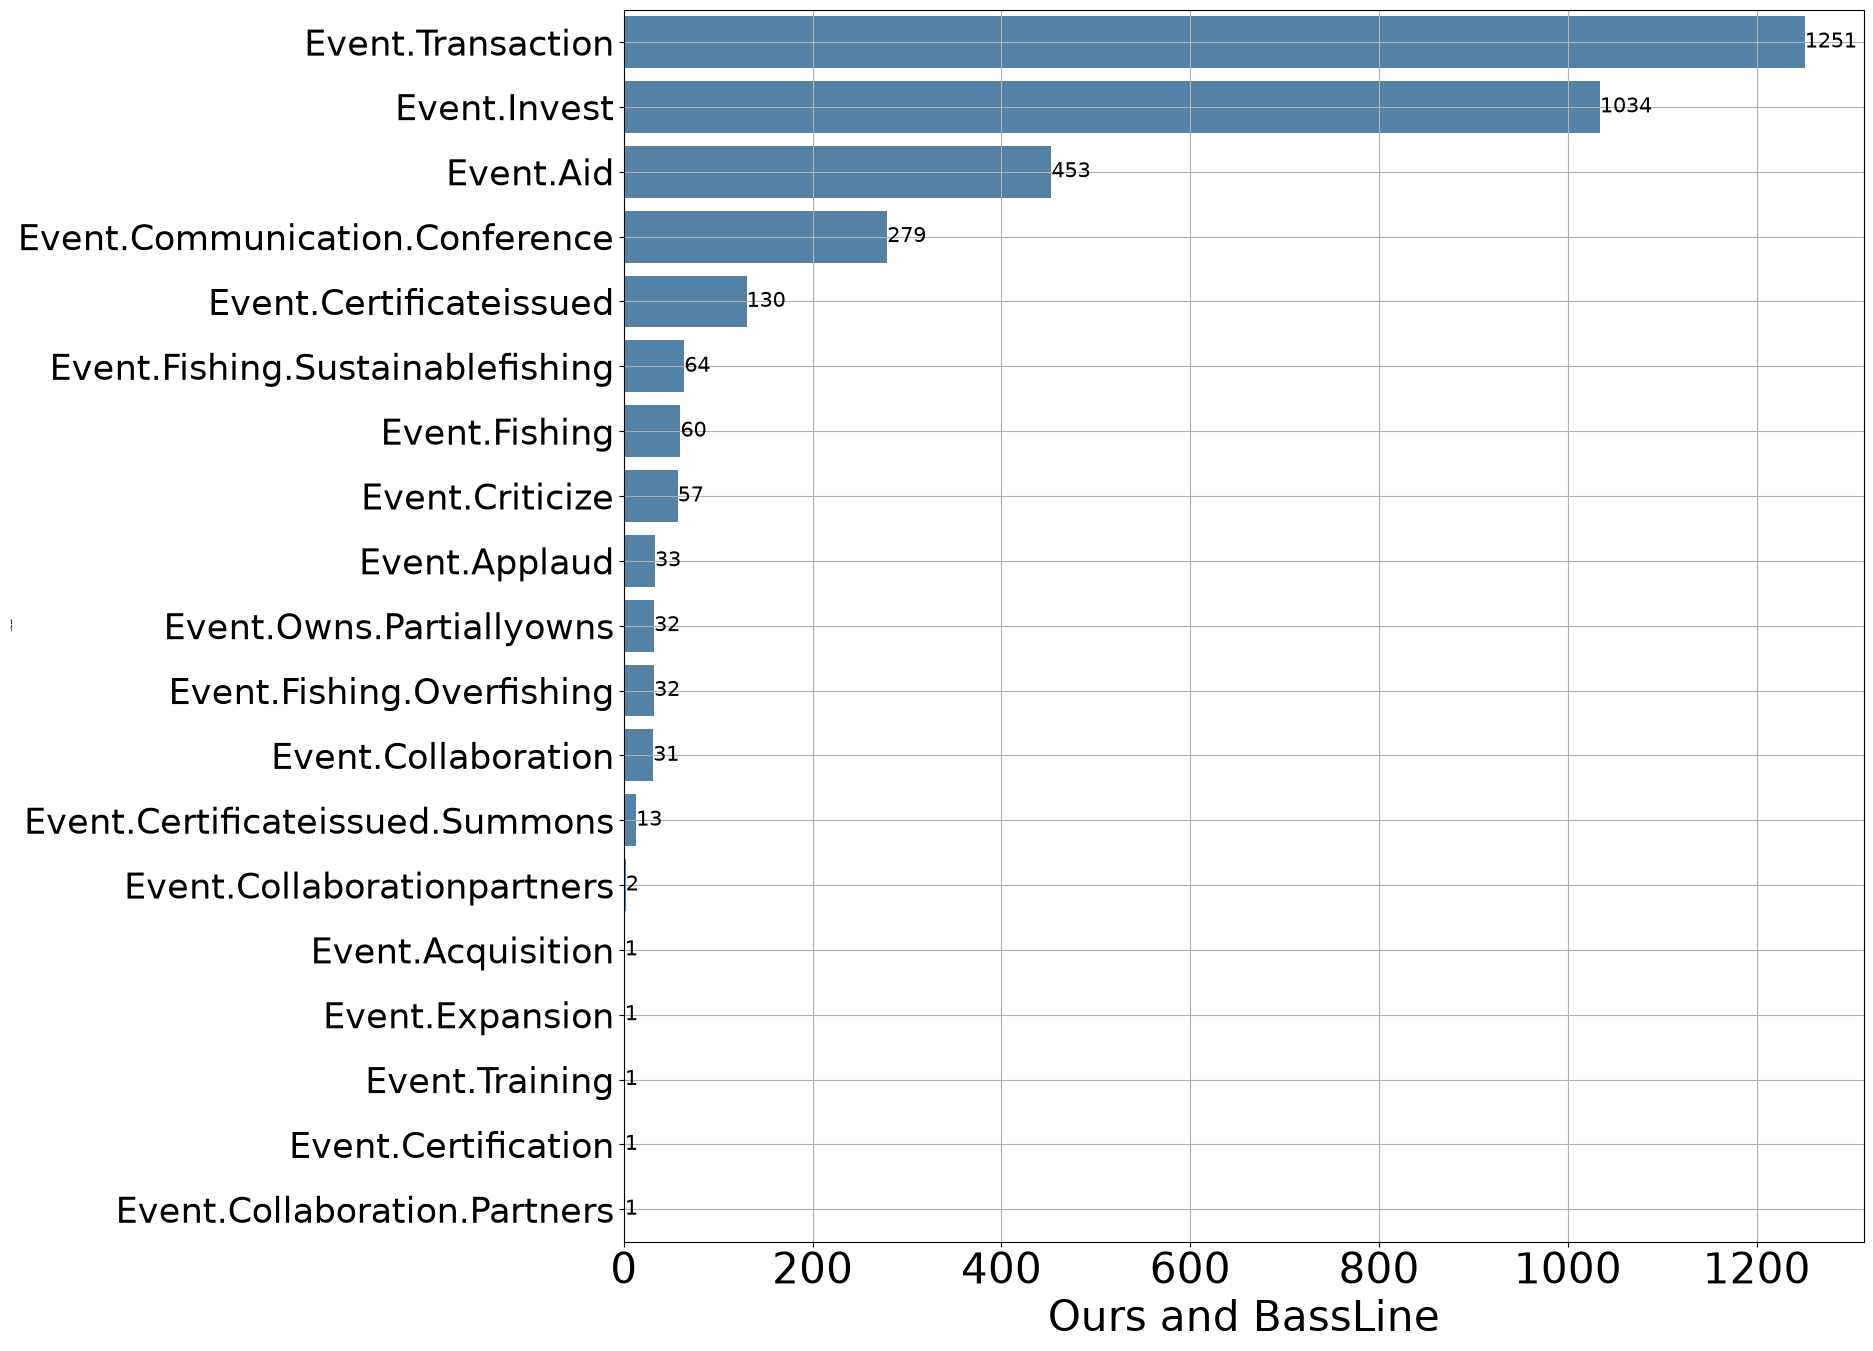

In [65]:
algorithm_name="ShadGPT"
_, ax = plt.subplots(figsize=(16,16), nrows=1, ncols=1, sharex=False, sharey=False)

data_df = ourGPT_diff_bassLine["type"].value_counts().reset_index()
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="steelblue",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

#sns_fig.set_title(f"Number of CVE-IDs cited per user, Total: {user_cve_sum}, Avg: {user_cve_mean}", fontsize=16)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'Ours and BassLine', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

ax.grid(True)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

#### Ours vs ShadGPT

In [66]:
ourGPT_and_shadGPT = pd.merge(ourGPT, shadGPT, on=["source", "type", "target", "_articleid"], how='inner', indicator=True)
ourGPT_and_shadGPT[ ourGPT_and_shadGPT["_merge"]=="both" ].sort_values(by="_articleid")

,source,type,target,context,_articleid,new_type,source_len,target_len,source_type,target_type,close_source_name,close_target_name,close_source_score,close_target_score,_date_added,_last_edited_date,_last_edited_by,_merge
0,alvarez plc,Event.Aid,marine_sanctuary,Aid to preserve vital ecosystems,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,NaN,alvarez plc,marine_sanctuary,0,1,2035-03-05,2035-03-05,Niklaus Oberon,both
15,alvarez plc,Event.Transaction,johnson-johnson,Collaborations and transactions,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,15,Entity.Organization.FishingCompany,Entity.Organization.Company,alvarez plc,johnson-johnson,0,0,2035-06-23,2035-06-23,Junior Shurdlu,both
14,alvarez plc,Event.Transaction,"maldonado, sanchez and jones",Collaborations and transactions,Alvarez PLC__0__0__Haacklee Herald,Positive,11,29,Entity.Organization.FishingCompany,NaN,alvarez plc,"maldonado, sanchez and jones",0,1,2035-06-23,2035-06-23,Junior Shurdlu,both
13,alvarez plc,Event.Transaction,"cain, simpson and hernandez",Collaborations and transactions,Alvarez PLC__0__0__Haacklee Herald,Positive,11,28,Entity.Organization.FishingCompany,NaN,alvarez plc,"cain, simpson and hernandez",0,1,2035-03-05,2035-03-05,Niklaus Oberon,both
12,alvarez plc,Event.Aid,marine_sanctuary,Actively supported marine sanctuary initiatives,Alvarez PLC__0__0__Haacklee Herald,Positive,11,16,Entity.Organization.FishingCompany,NaN,alvarez plc,marine_sanctuary,0,1,2035-06-23,2035-06-23,Junior Shurdlu,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1191,wu-hart,Event.Invest,tracking_system,Investments in tracking systems,Wu-Hart__0__0__Lomark Daily,Positive,7,15,Entity.Organization.FishingCompany,NaN,wu-hart,tracking_system,0,1,2035-05-06,2035-05-06,Jack Inch,both
1190,wu-hart,Event.Aid,marine_sanctuary,Contributions to marine sanctuary aid,Wu-Hart__0__0__Lomark Daily,Positive,7,16,Entity.Organization.FishingCompany,NaN,wu-hart,marine_sanctuary,0,1,2035-07-24,2035-07-24,Junior Shurdlu,both
1189,wu-hart,Event.Aid,marine_sanctuary,Contributions to marine sanctuary aid,Wu-Hart__0__0__Lomark Daily,Positive,7,16,Entity.Organization.FishingCompany,NaN,wu-hart,marine_sanctuary,0,1,2035-05-06,2035-05-06,Jack Inch,both
1193,wu-hart,Event.Invest,tracking_system,Investments in tracking systems,Wu-Hart__0__0__Lomark Daily,Positive,7,15,Entity.Organization.FishingCompany,NaN,wu-hart,tracking_system,0,1,2035-07-24,2035-07-24,Junior Shurdlu,both


In [67]:
ourGPT_diff_shadGPT = pd.merge(ourGPT, shadGPT, on=["source", "type", "target", "_articleid"], how='left', indicator=True)
ourGPT_diff_shadGPT[ ourGPT_diff_shadGPT["_merge"]=="left_only" ].sort_values(by="_articleid")

,source,type,target,context,_articleid,new_type,source_len,target_len,source_type,target_type,close_source_name,close_target_name,close_source_score,close_target_score,_date_added,_last_edited_date,_last_edited_by,_merge
10,alvarez plc,Event.Communication.Conference,"clements, allen and sullivan",Participation in conferences alongside industr...,Alvarez PLC__0__0__Haacklee Herald,Positive,11,28,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,alvarez plc,"clements, allen and sullivan",0,0,NaN,NaN,NaN,left_only
11,alvarez plc,Event.Communication.Conference,franco-stuart,Participation in conferences alongside industr...,Alvarez PLC__0__0__Haacklee Herald,Neutral,11,13,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,alvarez plc,franco-stuart,0,0,NaN,NaN,NaN,left_only
15,alvarez plc,Event.Transaction,barnett ltd,Collaborations and transactions,Alvarez PLC__0__0__Haacklee Herald,Positive,11,11,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,alvarez plc,barnett ltd,0,0,NaN,NaN,NaN,left_only
22,alvarez plc,Event.Invest,efficient sustainable nets,The company has been investing in efficient su...,Alvarez PLC__0__0__Lomark Daily,Positive,11,26,Entity.Organization.FishingCompany,NaN,alvarez plc,sustainable_nets,0,11,NaN,NaN,NaN,left_only
25,alvarez plc,Event.Transaction,eaton-osborne,It has also signed multiple fishing transactio...,Alvarez PLC__0__0__Lomark Daily,Positive,11,13,Entity.Organization.FishingCompany,NaN,alvarez plc,watson-gray,0,8,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3339,york-castillo,Event.Certificateissued,city of lomark,"approved allowed to do fishing in Wrasse Beds,...",York-Castillo__0__0__The News Buoy,Positive,13,14,Entity.Organization.FishingCompany,NaN,york-castillo,hughes-clark,0,10,NaN,NaN,NaN,left_only
3335,york-castillo,Event.Aid,local marine sanctuary,given $2000 to Local marine sanctuary as aid,York-Castillo__0__0__The News Buoy,Positive,13,22,Entity.Organization.FishingCompany,NaN,york-castillo,marine_sanctuary,0,7,NaN,NaN,NaN,left_only
3334,york-castillo,Event.Invest,efficiency,"investing in efficient sustainable nets, and t...",York-Castillo__0__0__The News Buoy,Neutral,13,10,Entity.Organization.FishingCompany,Entity.Commodity,york-castillo,efficiency,0,0,NaN,NaN,NaN,left_only
3336,york-castillo,Event.Transaction,cervantes-kramer,signed multiple fishing transactions with Cerv...,York-Castillo__0__0__The News Buoy,Neutral,13,16,Entity.Organization.FishingCompany,Entity.Organization.FishingCompany,york-castillo,cervantes-kramer,0,0,NaN,NaN,NaN,left_only


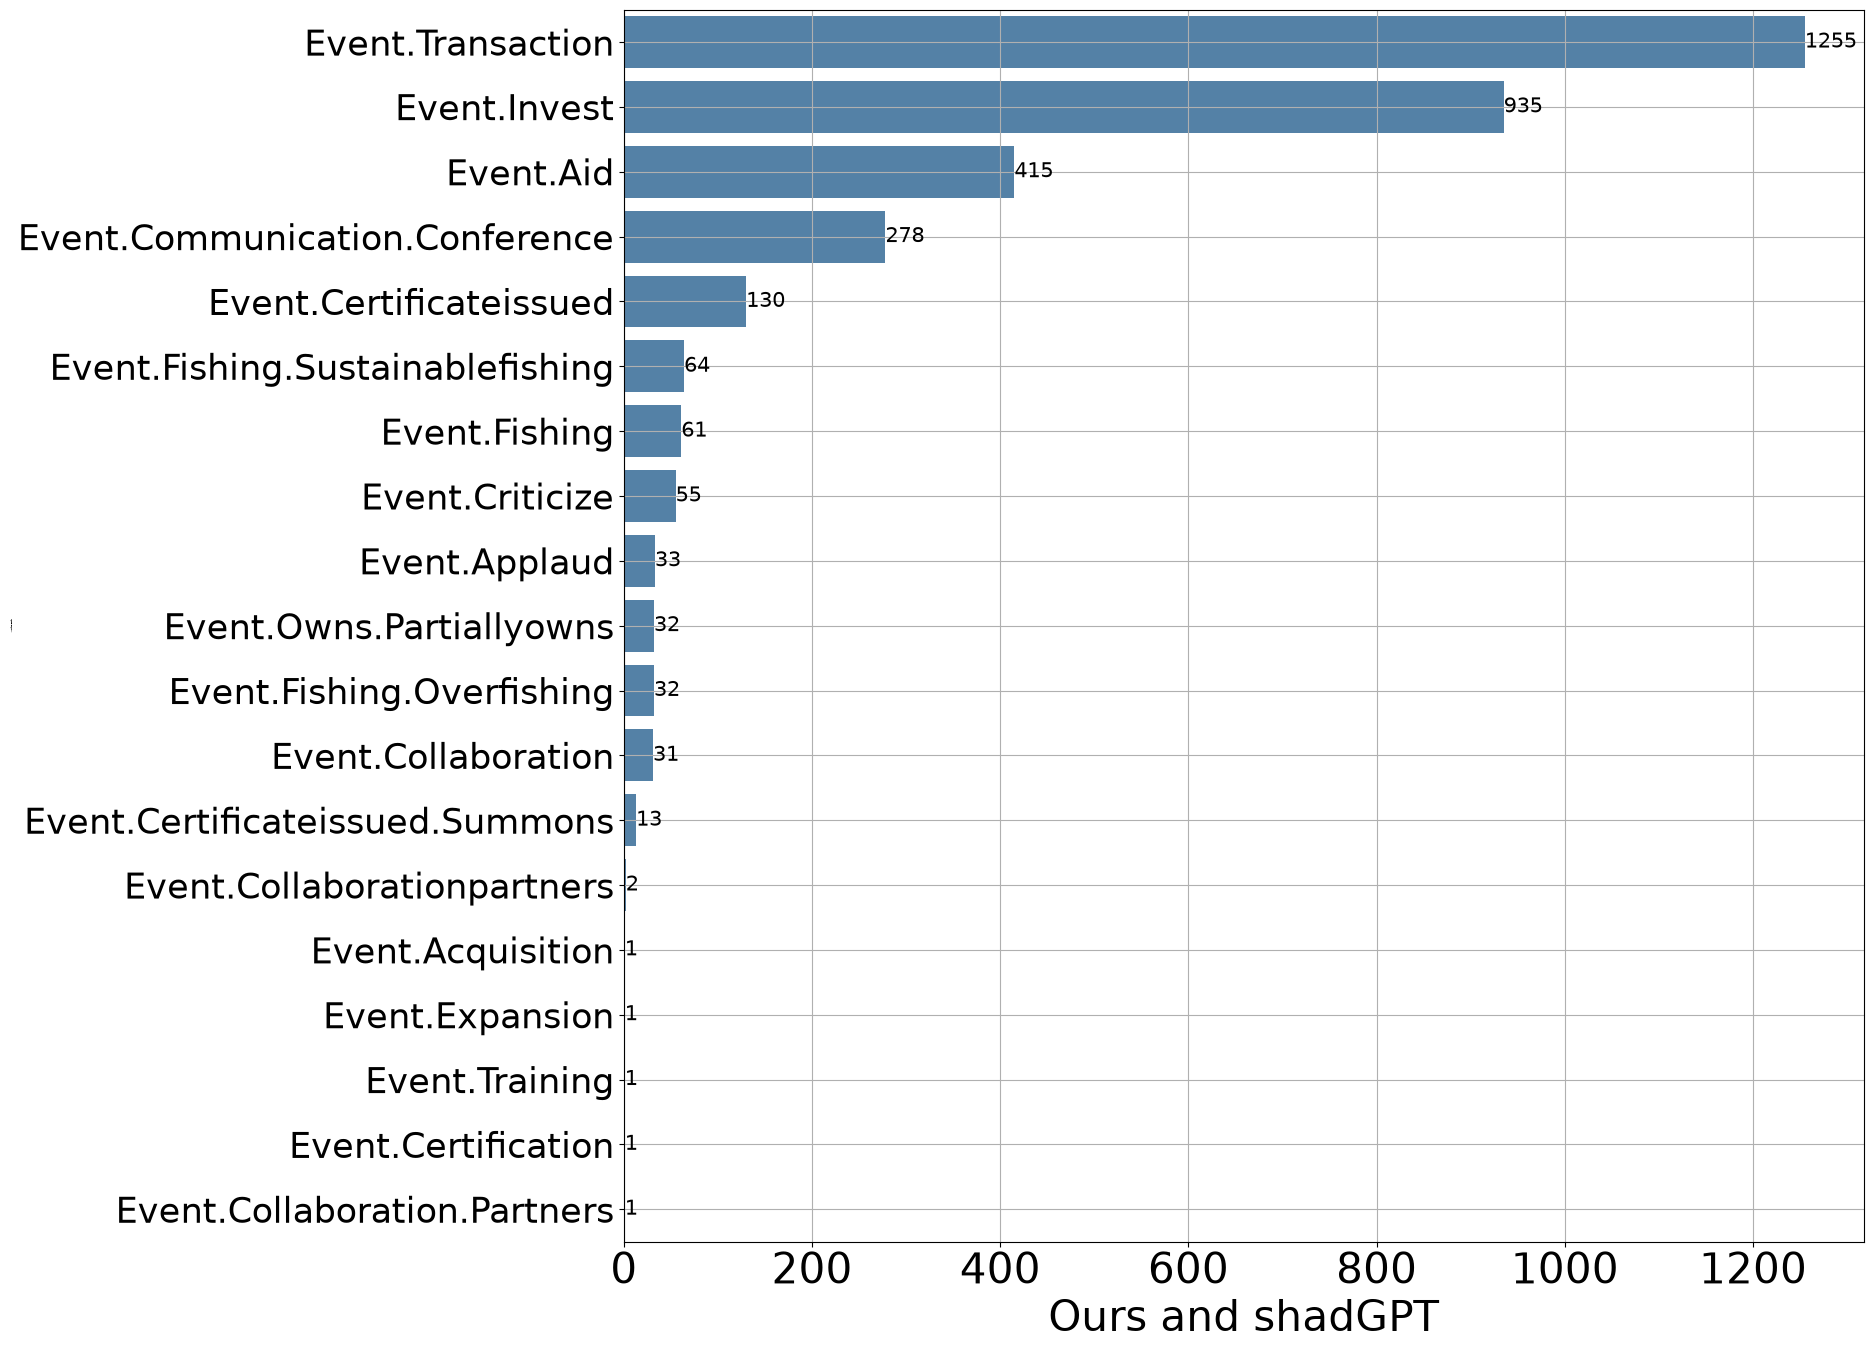

In [68]:
algorithm_name="ShadGPT"
_, ax = plt.subplots(figsize=(16,16), nrows=1, ncols=1, sharex=False, sharey=False)

data_df = ourGPT_diff_shadGPT["type"].value_counts().reset_index()
# data_df = df[df["_algorithm"]==algorithm_name]["new_type"].value_counts().reset_index()
# data_df = df["type"].value_counts().reset_index()

sns_fig = sns.barplot(
            data=data_df,
            x=data_df.columns[1],
            y=data_df.columns[0],
            ax=ax,
    orient="h",
            color="steelblue",
            # order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:9]
           )

#sns_fig.set_title(f"Number of CVE-IDs cited per user, Total: {user_cve_sum}, Avg: {user_cve_mean}", fontsize=16)
sns_fig.set_ylabel(f"Number of CVE-ID cited", fontsize=0)
sns_fig.set_xlabel(f'Ours and shadGPT', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=25)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

ax.grid(True)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

#### Visualizing links

#### Police reports

In [69]:
police_df = pd.read_excel(f"{DATA_PATH}csv/police_bias.ods", engine="odf", header=1)
police_df.drop(columns=["id"], inplace=True)
police_df["_articleid"] = police_df["Police"].apply(lambda x: x.replace("_Police.txt", "") )
police_df.rename(columns={"Journal.1": "_raw_source"}, inplace=True)
police_df.drop(columns=["Journal"], inplace=True)
police_df

,Police,Date,Location,Entity,Citation,Action,Found,Mentioned,_raw_source,Comment,_articleid
0,Jones Group__0__0__Haacklee Herald_Police.txt,2035-02-15,Nemo Reef,ArawakFish Cargo Ges.m.b.H.,MF-34569891,OverFishing,1.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
1,Jones Group__0__0__Haacklee Herald_Police.txt,2035-02-15,City Of South Paackland,ArawakFish Cargo Ges.m.b.H.,MF-34569891,Summon Issued,0.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
2,Jones Group__0__0__Haacklee Herald_Police.txt,2035-03-01,Don Limpet Preserve,ArawakFish Cargo Ges.m.b.H.,MF-34557991,OverFishing,0.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
3,Jones Group__0__0__Haacklee Herald_Police.txt,2035-03-01,City Of South Paackland,ArawakFish Cargo Ges.m.b.H.,MF-34569891,Summon Issued,0.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
4,Jones Group__0__0__Haacklee Herald_Police.txt,2035-03-10,City Of South Paackland,ArawakFish Cargo Ges.m.b.H.,MF-34569891,Convicted: OverFishing case,0.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
...,...,...,...,...,...,...,...,...,...,...,...
228,Wilcox-Nelson__0__0__Haacklee Herald_Police.txt,2035-02-08,Nemo Reef,Wilcox-Nelson,WN-20350208NR,Summons Issued,0.0,not mentioned,The News Buoy,"Positive comments, but police reports show oth...",Wilcox-Nelson__0__0__Haacklee Herald
229,Wilcox-Nelson__0__0__Haacklee Herald_Police.txt,2035-03-23,Don Limpet Preserve,Wilcox-Nelson,WN-20350323DLP,Summons Issued,0.0,not mentioned,The News Buoy,"Positive comments, but police reports show oth...",Wilcox-Nelson__0__0__Haacklee Herald
230,Wilcox-Nelson__0__0__Haacklee Herald_Police.txt,2035-03-23,City Of Paackland,Wilcox-Nelson,WN-20350323CP,Convicted,0.0,not mentioned,The News Buoy,"Positive comments, but police reports show oth...",Wilcox-Nelson__0__0__Haacklee Herald
231,Wilcox-Nelson__0__0__Haacklee Herald_Police.txt,2035-07-08,Don Limpet Preserve,Wilcox-Nelson,WN-20350708DLP,Summons Issued,0.0,not mentioned,The News Buoy,"Positive comments, but police reports show oth...",Wilcox-Nelson__0__0__Haacklee Herald


In [70]:
police_df

,Police,Date,Location,Entity,Citation,Action,Found,Mentioned,_raw_source,Comment,_articleid
0,Jones Group__0__0__Haacklee Herald_Police.txt,2035-02-15,Nemo Reef,ArawakFish Cargo Ges.m.b.H.,MF-34569891,OverFishing,1.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
1,Jones Group__0__0__Haacklee Herald_Police.txt,2035-02-15,City Of South Paackland,ArawakFish Cargo Ges.m.b.H.,MF-34569891,Summon Issued,0.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
2,Jones Group__0__0__Haacklee Herald_Police.txt,2035-03-01,Don Limpet Preserve,ArawakFish Cargo Ges.m.b.H.,MF-34557991,OverFishing,0.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
3,Jones Group__0__0__Haacklee Herald_Police.txt,2035-03-01,City Of South Paackland,ArawakFish Cargo Ges.m.b.H.,MF-34569891,Summon Issued,0.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
4,Jones Group__0__0__Haacklee Herald_Police.txt,2035-03-10,City Of South Paackland,ArawakFish Cargo Ges.m.b.H.,MF-34569891,Convicted: OverFishing case,0.0,mentioned,Haacklee Herald,NaN,Jones Group__0__0__Haacklee Herald
...,...,...,...,...,...,...,...,...,...,...,...
228,Wilcox-Nelson__0__0__Haacklee Herald_Police.txt,2035-02-08,Nemo Reef,Wilcox-Nelson,WN-20350208NR,Summons Issued,0.0,not mentioned,The News Buoy,"Positive comments, but police reports show oth...",Wilcox-Nelson__0__0__Haacklee Herald
229,Wilcox-Nelson__0__0__Haacklee Herald_Police.txt,2035-03-23,Don Limpet Preserve,Wilcox-Nelson,WN-20350323DLP,Summons Issued,0.0,not mentioned,The News Buoy,"Positive comments, but police reports show oth...",Wilcox-Nelson__0__0__Haacklee Herald
230,Wilcox-Nelson__0__0__Haacklee Herald_Police.txt,2035-03-23,City Of Paackland,Wilcox-Nelson,WN-20350323CP,Convicted,0.0,not mentioned,The News Buoy,"Positive comments, but police reports show oth...",Wilcox-Nelson__0__0__Haacklee Herald
231,Wilcox-Nelson__0__0__Haacklee Herald_Police.txt,2035-07-08,Don Limpet Preserve,Wilcox-Nelson,WN-20350708DLP,Summons Issued,0.0,not mentioned,The News Buoy,"Positive comments, but police reports show oth...",Wilcox-Nelson__0__0__Haacklee Herald
